In [95]:
from netCDF4 import Dataset as NetCDFFile 
import matplotlib.pyplot as plt
import numpy as np
import geopandas
import rasterio
from mpl_toolkits.basemap import Basemap

import rioxarray
import xarray
import fiona
from fiona import transform
from rasterio.plot import show
from rasterio.enums import Resampling

import glob, os

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.patches as patches


from PIL import Image
import matplotlib

import geopandas as gpd
from geocube.api.core import make_geocube
from geocube.rasterize import rasterize_points_griddata

import pyproj

from rasterio.enums import Resampling
from rasterio.windows import from_bounds

import pandas as pd
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.metrics import f1_score, cohen_kappa_score


In [32]:
def RMSE_spatial(true, pred):
    '''
    modified to work with 2D maps with a nan mask
    '''
    n = np.sum(~np.isnan(pred) & ~np.isnan(true))
    return np.sqrt(np.nansum((true - pred)**2)/n)

In [33]:
def MAPD(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the median absolute percentage difference (MAPD) '''
    return np.nanmedian(np.abs((y_true - y_est) / y_true)) * 100

In [34]:
def MAE_spatial(true, pred):
    '''
    modified to work with 2D maps with a nan mask
    '''
    n = np.sum(~np.isnan(pred) & ~np.isnan(true))
    print(n)
    return np.nansum(np.abs(true - pred))/n

In [35]:
def chla_NIR_rat(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    just use NIR ratio 708/666 with no coefficients
    '''
    ratio = df[Rrs_708] / df[Rrs_666]
    return ratio

def chla_NDCI(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    use NCDI NIR ratio (708-666)/(708+666)
    '''
    ratio = (df[Rrs_708] - df[Rrs_666]) / (df[Rrs_708] + df[Rrs_666])
    return ratio

def chla_OC4(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.3255, b=-2.7677,
             c=2.4409, d=-1.1288, e=-0.4990, returnX=False):
    '''4 band NASA alg (model L in claire neil paper)'''
    X = np.log10(np.array(np.max([df[Rrs_444], df[Rrs_492], df[Rrs_533]], axis=0)/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))

def chla_OC4_mod(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.3255, b=-2.7677,
             c=2.4409, d=-1.1288, e=-0.4990, returnX=False):
    '''4 band NASA alg (model L in claire neil paper)
    with Rrs_444 removed as we cant trust this one... '''
    X = np.log10(np.array(np.max([df[Rrs_492], df[Rrs_533]], axis=0)/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
    
def chla_OC3(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.2424, b=-2.2146,
             c=1.5193, d=-0.7702,
             e=-0.4291, returnX=False):
    '''3 band NASA alg (model M in claire neil paper)'''

    X = np.log10(np.array(np.max([df[Rrs_444],
                                  df[Rrs_492]],
                                 axis=0)/(df[Rrs_566]), dtype=float))

    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
                
def chla_OC2(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.2389, b=-1.9369,
             c=1.7627, d=-3.0777,
             e=-0.1054, returnX=False):
    '''2 band NASA alg (model N in claire neil paper)'''
    X = np.log10(np.array(df[Rrs_492]/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
    
def chla_RBD(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    NIR/red band difference
    '''
    return df[Rrs_708] - df[Rrs_666]

def chla_RBR3(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666', Rrs_866='Rrs_866'):
    return (df[Rrs_666]**-1 - df[Rrs_708]**-1) * df[Rrs_866]



In [43]:
# 24th June: (acolite for SD and S2)

# OC2_X
# S2_coeff:
# [-1467.06303114 -1727.49382179  -700.74577737  -114.52761458
#     -5.05365447]
# SD_coeff: 
# [-1.01227854e+03 -6.18968883e+02 -1.07200947e+02 -5.98662394e+00
#   7.00895076e-01]
# OC3_X
# S2_coeff:
# [-11.85424152  11.8345101    8.57455128  -2.22693676   0.32504707]
# SD_coeff: 
# [-446.86151603 -201.59773025   -4.79645411    1.20820977    0.71501882]
# OC4_X
# SD_coeff:
# [-1.81471459e+03  2.37511164e+02  6.79003127e+01 -5.19819726e+00
#   5.88600577e-01]


# 24th June: (acolite for SD and C2RCC-C2CX for S2)

# OC2_X
# S2_coeff:
# [ 52.75531716  -8.57170808 -13.63488302  -2.19803206   1.23223006]
# SD_coeff: 
# [-1.01227854e+03 -6.18968883e+02 -1.07200947e+02 -5.98662394e+00
#   7.00895076e-01]
# OC3_X
# S2_coeff:
# [ 52.21170505 -11.29312089 -14.27693158  -1.9865777    1.27518218]
# SD_coeff: 
# [-446.86151603 -201.59773025   -4.79645411    1.20820977    0.71501882]
# OC4_X
# SD_coeff:
# [-1.81471459e+03  2.37511164e+02  6.79003127e+01 -5.19819726e+00
#   5.88600577e-01]

# NIR
# SD_coeff:
# [-0.46770934  1.87657545]
# S2_coeff:
# [0.55386291 0.38444413]
# NDCI
# SD_coeff:
# [-1.87558786  1.55127892]
# S2_coeff:
# [1.67431552 0.98119468]
# RBD
# SD_coeff:
# [105.33996671   0.54325279]
# S2_coeff:
# [256.45606953   0.91358273]
# RBR3
# SD_coeff:
# [-0.32484211  1.50231199]
# S2_coeff:
# [5.61813791 0.99459553]
# OC2_X
# SD_coeff:
# [-1.31846999  0.75018395]
# S2_coeff:
# [-1.28859524  1.03740094]
# OC3_X
# SD_coeff:
# [-2.91864966  0.65474659]
# S2_coeff:
# [-1.24879141  1.04810289]
# ​


# more recently:
    
#     SD_coeff: ACOLITE
# [-49.84894256 -14.96809425   7.59868923  -0.86508297   0.64967369]
# S2_coeff: (C2RCC_CX)
# [ 5.4453959  -2.21279108 -0.22142106 -1.24401889  0.95622312]


# RBD
# SD_coeff:ACOLITE
# [ 4.47379048e+03 -1.42869963e+00]
# S2_coeff:(C2RCC_CX)
# [1.27155856e+04 1.10953794e+01]


# NDCI
# SD_coeff:ACOLITE
# [ 0.22784464 21.07090061]
# S2_coeff:(C2RCC_CX)
# [55.40625648 16.96064381]


# OLDER WORK BELOW:

# these are the coefficients I've found from S2_SD_nice fitting exercise
# note that coeffs in order from highest degree to lowest of the polynomial
# this is the way np.polyfit works

# OC2_X
# SD_coeff: 
# [506.06892637 392.15536774  94.24865753   5.08547344   0.66076503]
# S2_coeff:
# [-236.21822107 -223.27846193  -60.43881125   -5.14908542    0.85427622]
# OC3_X
# SD_coeff: 
# [-46.25366116 -12.96638103   7.29677618  -0.97394641   0.65452869]
# S2_coeff:
# [-46.52945764 -23.12084579   3.57432539   0.61589994   0.83770047]
# OC4_X
# SD_coeff:
# [-1.14494220e+03  1.42784407e+02  4.78583476e+01 -4.49757978e+00
#   6.59589727e-01]

# NIR
# SD_coeff:
# [-2.30073398 25.10614164]
# S2_coeff:
# [-14.93664794  49.26958544]
# NDCI
# SD_coeff:
# [ 0.26646029 21.06133001]
# S2_coeff:
# [-54.6739819   37.10374135]
# RBD
# SD_coeff:
# [ 4.63636160e+03 -1.71869443e+00]
# S2_coeff:
# [4.71412516e+03 1.59045623e+00]
# RBR3
# SD_coeff:
# [-7.79286034 31.40022337]
# S2_coeff:
# [-8.62183986 35.73590117]

In [76]:
# store coeffs in dicts

# SuperDoves:

SD_OC3_ac_coeff = {'e':-446.86151603, 'd': -201.59773025,
                   'c':-4.79645411, 'b': 1.20820977, 'a':0.71501882}

# SD_OC3_ac_lin_coeff = {'b':-2.63150769, 'a':0.76734456}

SD_OC3_ac_lin_coeff = {'b':-2.91864966, 'a':0.65474659}

# Sentinel 2:

# S2 c2rcc_CX:

S2_NDCI_c2cx_coeff = {'b':1.67431552, 'a':0.98119468}

S2_OC3_c2cx_lin_coeff = {'b':-1.24879141, 'a':1.04810289}

# S2 acolite:

S2_RBD_ac_coeff = {'b':100.51293461, 'a':0.68839788}

S2_OC3_lin_ac_coeff = {'b':-1.47736103, 'a':0.77251676}


# higher order OC algs - probably not sensible to use as these might be overfitted

S2_OC3_ac_coeff = {'e':-11.85424152, 'd':11.8345101, 'c':8.57455128,
                   'b':-2.22693676,'a':0.32504707}
S2_OC3_c2cx_coeff = {'e':52.21170505, 'd':-11.29312089,
                     'c':-14.27693158, 'b':-1.9865777, 'a':1.27518218}




In [86]:
# I think I might actually only use the best 2 of these
# OC3 and RBD were best!

# s2a: [443., 492., 560., 665., 704., 740., 783., 833., 865.])
# s2b: [442., 492., 559., 665., 704., 739., 780., 833., 864.]

def OC2_tuned_SD(df):
    return chla_OC2(df, 
                    a=0.66076503, b=5.08547344, c=94.24865753,
                    d=392.15536774, e=506.06892637)

def OC2_tuned_S2(df, sensor='S2A'):
    if sensor == 'S2A':
        Rrs_444 = 'Rrs_443'
        Rrs_566 = 'Rrs_560'
    if sensor == 'S2B':
        Rrs_444 = 'Rrs_442'
        Rrs_566 = 'Rrs_559'
    return chla_OC2(df, Rrs_444=Rrs_444, Rrs_492='Rrs_492',
                    Rrs_566=Rrs_566,
                    e=-236.21822107, d=-223.27846193, 
                    c=-60.43881125, b=-5.14908542, a=0.85427622)


def OC3_tuned_SD(df, filetype='l2w', e=-46.25366116, d=-12.96638103, c=7.29677618,
                        b=-0.97394641, a=0.65452869):
    # 
    if filetype == 'l2w':
        return chla_OC3(df,
                        e=e, d=d,
                        c=c, b=b, a=a,)
    elif filetype == 'l2r':
        return chla_OC3(df, Rrs_444='rhos_444', Rrs_492='rhos_492',
                         Rrs_533='rhos_533', Rrs_566='rhos_566',
                        e=e, d=d,
                        c=c, b=b, a=a,
                       )
    
def OC3_linear_SD(df, filetype='l2w', b=-2.63150769, a=0.76734456):
    if filetype == 'l2w':
        X = chla_OC3(df,
                        returnX=True)
    elif filetype == 'l2r':
        X = chla_OC3(df, Rrs_444='rhos_444', Rrs_492='rhos_492',
                         Rrs_533='rhos_533', Rrs_566='rhos_566',
                        returnX=True
                       )
    return 10**(b*X + a)


def OC3_linear_S2(df, sensor='S2A', filetype='acolite',
                    b=0.61589994, a=0.83770047):
    if filetype == 'acolite':
        Rrs_492='Rrs_492'
        if sensor == 'S2A':
            Rrs_444 = 'Rrs_443'
            Rrs_566 = 'Rrs_560'
        elif sensor == 'S2B':
            Rrs_444 = 'Rrs_442'
            Rrs_566 = 'Rrs_559'
        else:
            print('unknown sensor!!!! : ' + sensor)
    elif filetype == 'c2rcc':
        Rrs_444 = 'rrs_B1'
        Rrs_566 = 'rrs_B3'
        Rrs_492 = 'rrs_B2'
    X = chla_OC3(df, Rrs_444=Rrs_444,
                 Rrs_492=Rrs_492, Rrs_566=Rrs_566,
                 returnX=True)
    return 10**(b*X + a)
    
def OC3_tuned_S2(df, sensor='S2A', filetype='acolite',
                 e=-46.52945764, d=-23.12084579, c=3.57432539,
                    b=0.61589994, a=0.83770047):
    if filetype == 'acolite':
        Rrs_492='Rrs_492'
        if sensor == 'S2A':
            Rrs_444 = 'Rrs_443'
            Rrs_566 = 'Rrs_560'
        if sensor == 'S2B':
            Rrs_444 = 'Rrs_442'
            Rrs_566 = 'Rrs_559'
    elif filetype == 'c2rcc':
        Rrs_444 = 'rrs_B1'
        Rrs_566 = 'rrs_B3'
        Rrs_492 = 'rrs_B2'
    return chla_OC3(df, Rrs_444=Rrs_444, Rrs_492=Rrs_492, Rrs_566=Rrs_566,
                    a=a, b=b, c=c, d=d, e=e)



def OC4_tuned_SD(df):
    return chla_OC4(df,
                    e=-1.14494220e+03, d=1.42784407e+02,
                    c=4.78583476e+01, b=-4.49757978e+00,
                    a=6.59589727e-01)

def RBD_tuned_SD(df):
    rbd=chla_RBD(df)
    return np.polyval([4.63636160e+03, -1.71869443e+00],
                      rbd)
def RBD_tuned_S2(df, b=4.71412516e+03, a=1.59045623e+00,
                 Rrs_708='Rrs_704', Rrs_666='Rrs_665'):
    rbd=chla_RBD(df, Rrs_708=Rrs_708, Rrs_666=Rrs_666)
    return 10**np.polyval([b, a], rbd)

def NDCI_tuned_S2(df, a=55.40625648, b=16.96064381,
                  Rrs_708='rrs_B5', Rrs_666='rrs_B4'):
    ndci = chla_NDCI(df, Rrs_708=Rrs_708, Rrs_666=Rrs_666)
    return np.polyval([a, b], ndci)

def NDCI_tuned_S2(df, sensor='S2A', filetype='acolite',
                 b=1.82038262, a=0.96215122):
    if filetype == 'acolite':
        Rrs_666 = 'Rrs_665'
        Rrs_708 = 'Rrs_704'

    elif filetype == 'c2rcc':
        Rrs_666 = 'rrs_B4'
        Rrs_708 = 'rrs_B5'
        
    ndci = chla_NDCI(df, Rrs_708=Rrs_708, Rrs_666=Rrs_666)
    return 10**np.polyval([b, a], ndci)

In [90]:
with fiona.open("map_stuff/Download_airthrey_water_2483224/vml_5464100/ns/vml-ns89nw_Water_Area.shp",
                "r") as shapefile:
    
    shapes = [transform.transform_geom('EPSG:27700', 'EPSG:32630',
                                       feature["geometry"]) for feature in shapefile]
shapes = [shapes[10], shapes[28]] # indices of lhs and rhs of loch

In [90]:
# run the routine for all planet files
planet_L2W = []
for i, file in enumerate(glob.glob("planetData/acolite_output_L2W/*L2R.nc")):
    print(i, file)
    planet_L2W.append(file)
    xds = xarray.open_dataset(file)
    xds.rio.write_crs("epsg:32630", inplace=True)
    # do some chl-a calcs
    # can obviously do any math operation I want
    # can probably use my existing algorithm code if the bands are named similarly

    # this is a hacky way of ensuring the thing we put into xds is the right format
    a = xds['Rrs_666'].copy()
    a.data = OC3_linear_SD(xds, **SD_OC3_ac_lin_coeff)
    xds['chla_OC3_tuned_SD'] = a
    # make sure it is named properly
    xds['chla_OC3_tuned_SD'].attrs['parameter'] = 'chla_OC3_tuned_SD'

    a = xds['Rrs_666'].copy()
    a.data = RBD_tuned_SD(xds)
    xds['chla_RBD_tuned_SD'] = a
    # make sure it is named properly
    xds['chla_RBD_tuned_SD'].attrs['parameter'] = 'chla_RBD_tuned_SD'

    # IMPORTANT
    # change long variable names as these are used when we convert to raster as band names
    for var in list(xds.data_vars):
        try:
            xds[var].attrs['long_name'] = xds[var].attrs['parameter']
        except KeyError:
            pass

    xds.rio.to_raster('map_stuff/rasters/planet/temp.tif')
    # open raster and mask

    with rasterio.open('map_stuff/rasters/planet/temp.tif') as src:
        out_image, out_transform = rasterio.mask.mask(src, shapes, crop=False,
                                                      nodata=np.nan, all_touched=False)
        out_meta = src.meta
        print(src.meta)
        out_desc = src.descriptions
        
    # write masked raster data to a new raster file
    fname = 'map_stuff/rasters/planet/' + file[30:-3] + '.tif'

    out_meta.update({"driver": "GTiff",
                     "transform": out_transform})

    with rasterio.open(fname, "w", **out_meta) as dest:
        dest.write(out_image)
        dest.descriptions = out_desc

0 planetData/acolite_output_L2W/PlanetScope_2477_2023_08_26_11_06_47_L2R.nc


KeyError: "No variable named 'Rrs_666'. Variables on the dataset include ['transverse_mercator', 'x', 'y', 'lon', 'lat', ..., 'rhos_666', 'rhot_707', 'rhos_707', 'rhot_866', 'rhos_866']"

In [103]:
# run the routine for all planet files
# this time do L2R
planet_L2W = []
for i, file in enumerate(glob.glob("planetData/acolite_output_L2W/*L2R.nc")):
    print(i, file)
    planet_L2W.append(file)
    xds = xarray.open_dataset(file)
    xds.rio.write_crs("epsg:32630", inplace=True)
    # do some chl-a calcs
    # can obviously do any math operation I want
    # can probably use my existing algorithm code if the bands are named similarly

    # this is a hacky way of ensuring the thing we put into xds is the right format
    a = xds['rhos_666'].copy()
    a.data = OC3_linear_SD(xds, filetype='l2r', **SD_OC3_ac_lin_coeff)
    xds['chla_OC3_tuned_SD'] = a
    # make sure it is named properly
    xds['chla_OC3_tuned_SD'].attrs['parameter'] = 'chla_OC3_tuned_SD'

#     a = xds['rhos_666'].copy()
#     a.data = RBD_tuned_SD(xds)
#     xds['chla_RBD_tuned_SD'] = a
#     # make sure it is named properly
#     xds['chla_RBD_tuned_SD'].attrs['parameter'] = 'chla_RBD_tuned_SD'

    # IMPORTANT
    # change long variable names as these are used when we convert to raster as band names
    for var in list(xds.data_vars):
        try:
            xds[var].attrs['long_name'] = xds[var].attrs['parameter']
        except KeyError:
            pass

    xds.rio.to_raster('map_stuff/rasters/planet/temp.tif')
    # open raster and mask

    with rasterio.open('map_stuff/rasters/planet/temp.tif') as src:
        out_image, out_transform = rasterio.mask.mask(src, shapes, crop=False,
                                                      nodata=np.nan, all_touched=False)
        out_meta = src.meta
        print(src.meta)
        out_desc = src.descriptions
        
    # write masked raster data to a new raster file
    fname = 'map_stuff/rasters/planet/' + file[30:-3] + '.tif'

    out_meta.update({"driver": "GTiff",
                     "transform": out_transform})

    with rasterio.open(fname, "w", **out_meta) as dest:
        dest.write(out_image)
        dest.descriptions = out_desc

0 planetData/acolite_output_L2W/PlanetScope_2477_2023_08_26_11_06_47_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
1 planetData/acolite_output_L2W/PlanetScope_2416_2021_04_22_11_26_46_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
2 planetData/acolite_output_L2W/PlanetScope_248f_2023_03_07_11_05_07_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
3 planetData/acolite_output_L2W/PlanetScope_24c4_2023_04_07_10_29_27_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': 

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
31 planetData/acolite_output_L2W/PlanetScope_242d_2023_03_10_10_27_27_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
32 planetData/acolite_output_L2W/PlanetScope_2490_2023_03_11_11_03_49_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
33 planetData/acolite_output_L2W/PlanetScope_2405_2021_07_01_11_28_56_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0,

/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_25815/309652253.py:45: RuntimeWarning: divide by zero encountered in log10
  X = np.log10(np.array(np.max([df[Rrs_444],


{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
40 planetData/acolite_output_L2W/PlanetScope_2274_2022_02_27_11_13_50_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
41 planetData/acolite_output_L2W/PlanetScope_2262_2023_04_03_10_50_30_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
42 planetData/acolite_output_L2W/PlanetScope_2475_2022_11_28_11_02_12_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0,

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
70 planetData/acolite_output_L2W/PlanetScope_242b_2022_02_19_10_26_11_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
71 planetData/acolite_output_L2W/PlanetScope_2489_2022_11_21_10_58_24_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
72 planetData/acolite_output_L2W/PlanetScope_2424_2022_03_28_11_18_32_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0,

...

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
262 planetData/acolite_output_L2W/PlanetScope_2402_2022_07_04_11_16_57_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
263 planetData/acolite_output_L2W/PlanetScope_247f_2023_09_07_11_11_44_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
264 planetData/acolite_output_L2W/PlanetScope_2453_2021_05_30_10_36_59_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
292 planetData/acolite_output_L2W/PlanetScope_24b4_2023_05_16_10_30_33_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
293 planetData/acolite_output_L2W/PlanetScope_241e_2023_06_13_10_26_04_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
294 planetData/acolite_output_L2W/PlanetScope_2489_2023_03_27_11_05_15_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
323 planetData/acolite_output_L2W/PlanetScope_2458_2021_11_15_10_36_40_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
324 planetData/acolite_output_L2W/PlanetScope_245e_2021_04_05_10_34_33_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
325 planetData/acolite_output_L2W/PlanetScope_2413_2022_11_25_11_13_18_L2R.nc


/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_25815/309652253.py:45: RuntimeWarning: divide by zero encountered in log10
  X = np.log10(np.array(np.max([df[Rrs_444],


{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
326 planetData/acolite_output_L2W/PlanetScope_2460_2021_09_01_10_36_02_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
327 planetData/acolite_output_L2W/PlanetScope_227a_2022_11_28_11_06_18_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
328 planetData/acolite_output_L2W/PlanetScope_2212_2021_04_22_10_34_13_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0

In [44]:
xds['x']

<xarray.DataArray 'x' (x: 298)> Size: 2kB
array([442474.5, 442477.5, 442480.5, ..., 443359.5, 443362.5, 443365.5])
Coordinates:
    transverse_mercator  int64 8B 0
  * x                    (x) float64 2kB 4.425e+05 4.425e+05 ... 4.434e+05
Attributes:
    standard_name:  projection_x_coordinate
    long_name:      x coordinate of projection
    units:          m

In [92]:
for i, file in enumerate(glob.glob("S2_downloads/acolite_output/*L2W.nc")):
    print(i, file)
    
# for i, file in enumerate(glob.glob("C2RCC/full_S2_c2rcc_complex_X/*.nc")):
#     print(i, file)

0 S2_downloads/acolite_output/S2A_MSI_2023_10_07_11_45_36_T30VVH_L2W.nc
1 S2_downloads/acolite_output/S2A_MSI_2023_07_19_11_45_40_T30VVH_L2W.nc
2 S2_downloads/acolite_output/S2B_MSI_2023_04_22_11_35_41_T30VVH_L2W.nc
3 S2_downloads/acolite_output/S2B_MSI_2023_09_02_11_45_40_T30VVH_L2W.nc
4 S2_downloads/acolite_output/S2B_MSI_2022_10_07_11_45_33_T30VVH_L2W.nc
5 S2_downloads/acolite_output/S2A_MSI_2022_04_22_11_35_44_T30VVH_L2W.nc
6 S2_downloads/acolite_output/S2A_MSI_2023_07_16_11_35_44_T30VVH_L2W.nc
7 S2_downloads/acolite_output/S2B_MSI_2023_10_12_11_45_37_T30VVH_L2W.nc
8 S2_downloads/acolite_output/S2A_MSI_2022_07_04_11_45_49_T30VVH_L2W.nc
9 S2_downloads/acolite_output/S2A_MSI_2023_03_08_11_35_34_T30VVH_L2W.nc
10 S2_downloads/acolite_output/S2B_MSI_2023_09_29_11_35_41_T30VVH_L2W.nc
11 S2_downloads/acolite_output/S2A_MSI_2023_09_24_11_35_41_T30VVH_L2W.nc
12 S2_downloads/acolite_output/S2B_MSI_2023_07_11_11_35_44_T30VVH_L2W.nc
13 S2_downloads/acolite_output/S2B_MSI_2023_04_15_11_45_36_T3

In [98]:
file[28:-3]

'S2B_MSI_2022_03_28_11_35_36_T30VVH_L2W'

In [104]:
for i, file in enumerate(glob.glob("S2_downloads/acolite_output/*L2R.nc")):
    print(i, file)

0 S2_downloads/acolite_output/S2B_MSI_2023_08_20_11_35_44_T30VVH_L2R.nc
1 S2_downloads/acolite_output/S2A_MSI_2022_10_12_11_45_41_T30VVH_L2R.nc
2 S2_downloads/acolite_output/S2B_MSI_2022_03_31_11_45_32_T30VVH_L2R.nc
3 S2_downloads/acolite_output/S2A_MSI_2023_09_27_11_45_38_T30VVH_L2R.nc
4 S2_downloads/acolite_output/S2A_MSI_2023_04_07_11_35_39_T30VVH_L2R.nc
5 S2_downloads/acolite_output/S2A_MSI_2022_08_20_11_35_52_T30VVH_L2R.nc
6 S2_downloads/acolite_output/S2B_MSI_2023_03_06_11_45_39_T30VVH_L2R.nc
7 S2_downloads/acolite_output/S2A_MSI_2023_03_11_11_45_31_T30VVH_L2R.nc
8 S2_downloads/acolite_output/S2A_MSI_2023_10_14_11_35_37_T30VVH_L2R.nc
9 S2_downloads/acolite_output/S2A_MSI_2023_10_24_11_35_39_T30VVH_L2R.nc
10 S2_downloads/acolite_output/S2B_MSI_2022_10_24_11_35_38_T30VVH_L2R.nc
11 S2_downloads/acolite_output/S2A_MSI_2023_09_04_11_35_44_T30VVH_L2R.nc
12 S2_downloads/acolite_output/S2A_MSI_2023_10_07_11_45_36_T30VVH_L2R.nc
13 S2_downloads/acolite_output/S2B_MSI_2023_04_22_11_35_41_T3

In [112]:
# run the routine for all S2 acolite files
# this time do L2R
planet_L2W = []
for i, file in enumerate(glob.glob("S2_downloads/acolite_output/*L2W.nc")):
    print(i, file)
    planet_L2W.append(file)
    xds = xarray.open_dataset(file)
    xds.rio.write_crs("epsg:32630", inplace=True)
    # do some chl-a calcs
    # can obviously do any math operation I want
    # can probably use my existing algorithm code if the bands are named similarly
    sensor = file[28:31]
    print(sensor)
    # this is a hacky way of ensuring the thing we put into xds is the right format
    a = xds['Rrs_665'].copy()
    a.data = OC3_linear_S2(xds, sensor=sensor,
                          filetype='acolite', **S2_OC3_lin_ac_coeff)
    xds['chla_OC3_tuned_S2'] = a
    # make sure it is named properly
    xds['chla_OC3_tuned_S2'].attrs['parameter'] = 'chla_OC3_tuned_S2'

    a = xds['Rrs_665'].copy()
    a.data = RBD_tuned_S2(xds, #sensor=sensor,
                          #filetype='acolite',
                          **S2_RBD_ac_coeff)
    xds['chla_RBD_tuned_S2'] = a
    # make sure it is named properly
    xds['chla_RBD_tuned_S2'].attrs['parameter'] = 'chla_RBD_tuned_S2'


    # IMPORTANT
    # change long variable names as these are used when we convert to raster as band names
    for var in list(xds.data_vars):
        try:
            xds[var].attrs['long_name'] = xds[var].attrs['parameter']
        except KeyError:
            pass

    xds.rio.to_raster('map_stuff/rasters/planet/temp.tif')
    # open raster and mask

    with rasterio.open('map_stuff/rasters/planet/temp.tif') as src:
        out_image, out_transform = rasterio.mask.mask(src, shapes, crop=False,
                                                      nodata=np.nan, all_touched=False)
        out_meta = src.meta
        print(src.meta)
        out_desc = src.descriptions
        
    # write masked raster data to a new raster file
    fname = 'map_stuff/rasters/Sentinel2/acolite/' + file[28:-3] + '.tif'

    out_meta.update({"driver": "GTiff",
                     "transform": out_transform})

    with rasterio.open(fname, "w", **out_meta) as dest:
        dest.write(out_image)
        dest.descriptions = out_desc

0 S2_downloads/acolite_output/S2A_MSI_2023_10_07_11_45_36_T30VVH_L2W.nc
S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
1 S2_downloads/acolite_output/S2A_MSI_2023_07_19_11_45_40_T30VVH_L2W.nc
S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
2 S2_downloads/acolite_output/S2B_MSI_2023_04_22_11_35_41_T30VVH_L2W.nc
S2B
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
3 S2_downloads/acolite_output/S2B_MSI_2023_09_02_11_45_40_T30VVH_L2W.nc
S2B
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs'

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
35 S2_downloads/acolite_output/S2B_MSI_2023_07_04_11_45_41_T30VVH_L2W.nc
S2B
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
36 S2_downloads/acolite_output/S2A_MSI_2023_04_10_11_45_36_T30VVH_L2W.nc
S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
37 S2_downloads/acolite_output/S2B_MSI_2023_08_10_11_35_44_T30VVH_L2W.nc
S2B
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
65 S2_downloads/acolite_output/S2A_MSI_2022_09_12_11_45_46_T30VVH_L2W.nc
S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
66 S2_downloads/acolite_output/S2A_MSI_2022_03_23_11_35_42_T30VVH_L2W.nc
S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
67 S2_downloads/acolite_output/S2B_MSI_2023_09_22_11_45_39_T30VVH_L2W.nc
S2B
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0

S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
95 S2_downloads/acolite_output/S2A_MSI_2023_05_07_11_35_39_T30VVH_L2W.nc
S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
96 S2_downloads/acolite_output/S2B_MSI_2022_03_08_11_35_37_T30VVH_L2W.nc
S2B
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
97 S2_downloads/acolite_output/S2B_MSI_2023_06_11_11_35_44_T30VVH_L2W.nc
S2B
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
    

In [91]:
# run the routine for all S2 acolite files

# just doing a subset of 2021 files


# this time do L2R
planet_L2W = []
for i, file in enumerate(glob.glob("S2_downloads/Download_Sentinel_2/acolite_output/*L2W.nc")):
    print(i, file)
    planet_L2W.append(file)
    xds = xarray.open_dataset(file)
    xds.rio.write_crs("epsg:32630", inplace=True)
    # do some chl-a calcs
    # can obviously do any math operation I want
    # can probably use my existing algorithm code if the bands are named similarly
    sensor = file[48:51]
    print(sensor)
    # this is a hacky way of ensuring the thing we put into xds is the right format
    a = xds['Rrs_665'].copy()
    a.data = OC3_linear_S2(xds, sensor=sensor,
                          filetype='acolite', **S2_OC3_lin_ac_coeff)
    xds['chla_OC3_tuned_S2'] = a
    # make sure it is named properly
    xds['chla_OC3_tuned_S2'].attrs['parameter'] = 'chla_OC3_tuned_S2'

    a = xds['Rrs_665'].copy()
    a.data = RBD_tuned_S2(xds, #sensor=sensor,
                          #filetype='acolite',
                          **S2_RBD_ac_coeff)
    xds['chla_RBD_tuned_S2'] = a
    # make sure it is named properly
    xds['chla_RBD_tuned_S2'].attrs['parameter'] = 'chla_RBD_tuned_S2'


    # IMPORTANT
    # change long variable names as these are used when we convert to raster as band names
    for var in list(xds.data_vars):
        try:
            xds[var].attrs['long_name'] = xds[var].attrs['parameter']
        except KeyError:
            pass

    xds.rio.to_raster('map_stuff/rasters/planet/temp.tif')
    # open raster and mask

    with rasterio.open('map_stuff/rasters/planet/temp.tif') as src:
        out_image, out_transform = rasterio.mask.mask(src, shapes, crop=False,
                                                      nodata=np.nan, all_touched=False)
        out_meta = src.meta
        print(src.meta)
        out_desc = src.descriptions
        
    # write masked raster data to a new raster file
    fname = 'map_stuff/rasters/Sentinel2/acolite/' + file[48:-3] + '.tif'

    out_meta.update({"driver": "GTiff",
                     "transform": out_transform})

    with rasterio.open(fname, "w", **out_meta) as dest:
        dest.write(out_image)
        dest.descriptions = out_desc

0 S2_downloads/Download_Sentinel_2/acolite_output/S2A_MSI_2021_07_16_11_35_42_T30VVH_L2W.nc
S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
1 S2_downloads/Download_Sentinel_2/acolite_output/S2A_MSI_2021_07_26_11_35_42_T30VVH_L2W.nc
S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
2 S2_downloads/Download_Sentinel_2/acolite_output/S2A_MSI_2021_07_19_11_45_39_T30VVH_L2W.nc
S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
3 S2_downloads/Download_Sentinel_2/acolite_output/S2A_MSI_2021_07_06_11_35_42_T30VVH_L2W.nc
S2A
{'driver': 'GTiff', 'd

In [84]:
file[48:51]

'S2A'

In [83]:
file

'S2_downloads/Download_Sentinel_2/acolite_output/S2A_MSI_2021_07_16_11_35_42_T30VVH_L2W.nc'

In [90]:
# run the routine for all Sentinel-2 files
planet_L2W = []
for i, file in enumerate(glob.glob("S2_downloads/sdfdsf/*.nc")):
    print(i, file)
    planet_L2W.append(file)
    xds = xarray.open_dataset(file, decode_cf=True)
    xds.rio.write_crs("epsg:32630", inplace=True)
    # do some chl-a calcs
    # can obviously do any math operation I want
    # can probably use my existing algorithm code if the bands are named similarly
    sensor = file[40:43] # this gets the S2A or S2B section of the filename
    # ^^ use file[28:31] for acolite
    print('sensor: ' + sensor)
    # this is a hacky way of ensuring the thing we put into xds is the right format
    a = xds['rrs_B4'].copy() # Rrs_665
    a.data = OC3_tuned_S2(xds, sensor=sensor, filetype='c2rcc', S2_OC3_c2cx_coeff)
    xds['chla_OC3_tuned_S2'] = a
    # make sure it is named properly
    xds['chla_OC3_tuned_S2'].attrs['parameter'] = 'chla_OC3_tuned_S2'

#     a = xds['Rrs_665'].copy()
#     a.data = RBD_tuned_S2(xds)
#     xds['chla_RBD_tuned_S2'] = a
#     # make sure it is named properly
#     xds['chla_RBD_tuned_S2'].attrs['parameter'] = 'chla_RBD_tuned_S2'

    # IMPORTANT
    # change long variable names as these are used when we convert to raster as band names
    for var in list(xds.data_vars):
        try:
            xds[var].attrs['long_name'] = xds[var].attrs['parameter']
        except KeyError:
            pass

    xds.rio.to_raster('map_stuff/rasters/Sentinel2/temp.tif')
    # open raster and mask

    with rasterio.open('map_stuff/rasters/Sentinel2/temp.tif') as src:
        out_image, out_transform = rasterio.mask.mask(src, shapes, crop=False,
                                                      nodata=np.nan, all_touched=False)
        out_meta = src.meta
        print(src.meta)
        out_desc = src.descriptions
        
    # write masked raster data to a new raster file
    fname = 'map_stuff/rasters/Sentinel2/c2rcc_CX' + file[40:-3] + '.tif'

    out_meta.update({"driver": "GTiff",
                     "transform": out_transform})

    with rasterio.open(fname, "w", **out_meta) as dest:
        dest.write(out_image)
        dest.descriptions = out_desc

SyntaxError: positional argument follows keyword argument (3840455362.py, line 16)

In [107]:
# run the routine for all Sentinel-2 files

# NEED A SLIGHTLY different approach for the c2rcc_CX files as they have annoying lats and lons

planet_L2W = []
for i, file in enumerate(glob.glob("C2RCC/full_S2_c2rcc_complex_X/*.nc")):
    print(i, file)
    planet_L2W.append(file)
    xds = xarray.open_dataset(file, decode_cf=True, engine='netcdf4',
                              decode_coords=False, # don't add coords automatically
                              mask_and_scale=True)
    
    
    xds.rio.write_crs("epsg:32630", inplace=True)
    # now need to manually create the x, y which we'd expect from epsg:32630
    transformer = pyproj.Transformer.from_crs('wgs84', 32630)
    x, y = transformer.transform(xds.lat, xds.lon)
    xds.coords['x'] = x[0, :]
    xds.coords['y'] = y[:, 0]
    
    # do some chl-a calcs
    # can obviously do any math operation I want
    # can probably use my existing algorithm code if the bands are named similarly
    sensor = file[40:43] # this gets the S2A or S2B section of the filename
    # ^^ use file[28:31] for acolite
    print('sensor: ' + sensor)
    # this is a hacky way of ensuring the thing we put into xds is the right format
    a = xds['rrs_B4'].copy() # Rrs_665
    a.data = OC3_tuned_S2(xds, sensor=sensor, filetype='c2rcc',
                          **SD_OC3_ac_coeff)
    xds['chla_OC3_tuned_S2'] = a
    # make sure it is named properly
    xds['chla_OC3_tuned_S2'].attrs['parameter'] = 'chla_OC3_tuned_S2'

    a = xds['rrs_B4'].copy()

    a.data = NDCI_tuned_S2(xds, **S2_NDCI_c2cx_coeff,
                           filetype='c2rcc')
    xds['chla_NDCI_tuned_S2'] = a
    # make sure it is named properly
    xds['chla_NDCI_tuned_S2'].attrs['parameter'] = 'chla_NDCI_tuned_S2'
    
#     a = xds['rrs_B4'].copy()

#     a.data = NDCI_tuned_S2(xds)
#     xds['chla_NDCI_tuned_S2'] = a
#     # make sure it is named properly
#     xds['chla_NDCI_tuned_S2'].attrs['parameter'] = 'chla_NDCI_tuned_S2'

    # IMPORTANT
    # change long variable names as these are used when we convert to raster as band names
    for var in list(xds.data_vars):
        try:
            xds[var].attrs['long_name'] = xds[var].attrs['parameter']
        except KeyError:
            pass

    # the netcdf file has lots of variables with values which rio.to_raster doesn't handle well
    # therefore, only select the bands we're interested in
    xds[['chla_OC3_tuned_S2',
#          'chla_RBD_tuned_S2',
         'chla_NDCI_tuned_S2']].rio.to_raster('map_stuff/rasters/Sentinel2/temp.tif')
    # open raster and mask

    with rasterio.open('map_stuff/rasters/Sentinel2/temp.tif') as src:
        out_image, out_transform = rasterio.mask.mask(src, shapes, crop=False,
                                                      nodata=np.nan, all_touched=False)
        out_meta = src.meta
        print(src.meta)
        out_desc = src.descriptions
        
    # write masked raster data to a new raster file
    fname = 'map_stuff/rasters/Sentinel2/c2rcc_CX/' + file[40:-3] + '.tif'

    out_meta.update({"driver": "GTiff",
                     "transform": out_transform})

    with rasterio.open(fname, "w", **out_meta) as dest:
        dest.write(out_image)
        dest.descriptions = out_desc

0 C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2A_MSIL1C_20231024T113321_N0509_R080_T30VVH_20231024T133156.nc
sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
1 C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2A_MSIL1C_20220714T114401_N0400_R123_T30VVH_20220714T165848.nc
sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
2 C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2A_MSIL1C_20230924T113321_N0509_R080_T30VVH_20230924T133411.nc
sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 

sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
25 C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2B_MSIL1C_20230714T114349_N0509_R123_T30VVH_20230714T134343.nc
sensor: S2B
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
26 C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2A_MSIL1C_20220704T114401_N0400_R123_T30VVH_20220704T151910.nc
sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
27 C2RCC/full_S2_c2rcc_complex_X/

sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
50 C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2A_MSIL1C_20230331T114351_N0509_R123_T30VVH_20230331T151932.nc
sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
51 C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2A_MSIL1C_20220323T113321_N0400_R080_T30VVH_20220323T134849.nc
sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
52 C2RCC/full_S2_c2rcc_complex_X/

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
73 C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2A_MSIL1C_20230805T113321_N0509_R080_T30VVH_20230805T151256.nc
sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
74 C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2B_MSIL1C_20230323T113319_N0509_R080_T30VVH_20230323T165050.nc
sensor: S2B
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
75 C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2

sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
98 C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2A_MSIL1C_20230815T113321_N0509_R080_T30VVH_20230815T151206.nc
sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
99 C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2B_MSIL1C_20220729T114359_N0400_R123_T30VVH_20220729T121829.nc
sensor: S2B
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
100 C2RCC/full_S2_c2rcc_complex_X

In [58]:
# run the routine for all Sentinel-2 files FROM 2021 - 2024

# NEED A SLIGHTLY different approach for the c2rcc_CX files as they have annoying lats and lons

planet_L2W = []
for i, file in enumerate(glob.glob("C2RCC/C2RCC_CX_21_24/*.nc")):
    print(i, file)
    planet_L2W.append(file)
    xds = xarray.open_dataset(file, decode_cf=True, engine='netcdf4',
                              decode_coords=False, # don't add coords automatically
                              mask_and_scale=True)
    
    
    xds.rio.write_crs("epsg:32630", inplace=True)
    # now need to manually create the x, y which we'd expect from epsg:32630
    transformer = pyproj.Transformer.from_crs('wgs84', 32630)
    x, y = transformer.transform(xds.lat, xds.lon)
    xds.coords['x'] = x[0, :]
    xds.coords['y'] = y[:, 0]
    
    # do some chl-a calcs
    # can obviously do any math operation I want
    # can probably use my existing algorithm code if the bands are named similarly
    sensor = file[40:43] # this gets the S2A or S2B section of the filename
    # ^^ use file[28:31] for acolite
    print('sensor: ' + sensor)
    # this is a hacky way of ensuring the thing we put into xds is the right format
    a = xds['rrs_B4'].copy() # Rrs_665
    a.data = OC3_tuned_S2(xds, sensor=sensor, filetype='c2rcc',
                          **SD_OC3_ac_coeff)
    xds['chla_OC3_tuned_S2'] = a
    # make sure it is named properly
    xds['chla_OC3_tuned_S2'].attrs['parameter'] = 'chla_OC3_tuned_S2'

    a = xds['rrs_B4'].copy()

    a.data = NDCI_tuned_S2(xds, **S2_NDCI_c2cx_coeff,
                           filetype='c2rcc')
    xds['chla_NDCI_tuned_S2'] = a
    # make sure it is named properly
    xds['chla_NDCI_tuned_S2'].attrs['parameter'] = 'chla_NDCI_tuned_S2'
    
#     a = xds['rrs_B4'].copy()

#     a.data = NDCI_tuned_S2(xds)
#     xds['chla_NDCI_tuned_S2'] = a
#     # make sure it is named properly
#     xds['chla_NDCI_tuned_S2'].attrs['parameter'] = 'chla_NDCI_tuned_S2'

    # IMPORTANT
    # change long variable names as these are used when we convert to raster as band names
    for var in list(xds.data_vars):
        try:
            xds[var].attrs['long_name'] = xds[var].attrs['parameter']
        except KeyError:
            pass

    # the netcdf file has lots of variables with values which rio.to_raster doesn't handle well
    # therefore, only select the bands we're interested in
    xds[['chla_OC3_tuned_S2',
#          'chla_RBD_tuned_S2',
         'chla_NDCI_tuned_S2']].rio.to_raster('map_stuff/rasters/Sentinel2/temp.tif')
    # open raster and mask

    with rasterio.open('map_stuff/rasters/Sentinel2/temp.tif') as src:
        out_image, out_transform = rasterio.mask.mask(src, shapes, crop=False,
                                                      nodata=np.nan, all_touched=False)
        out_meta = src.meta
        print(src.meta)
        out_desc = src.descriptions
        
    # write masked raster data to a new raster file
    fname = 'map_stuff/rasters/Sentinel2/c2rcc_CX_21_24/' + file[25:-3] + '.tif'

    out_meta.update({"driver": "GTiff",
                     "transform": out_transform})

    with rasterio.open(fname, "w", **out_meta) as dest:
        dest.write(out_image)
        dest.descriptions = out_desc

0 C2RCC/C2RCC_CX_21_24/C2X_S2A_MSIL1C_20211116T114351_N0301_R123_T30VVH_20211116T134054.nc
sensor: 111
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
1 C2RCC/C2RCC_CX_21_24/C2X_S2B_MSIL1C_20210306T114349_N0500_R123_T30VVH_20230528T191248.nc
sensor: 030
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
2 C2RCC/C2RCC_CX_21_24/C2X_S2B_MSIL1C_20221116T114349_N0400_R123_T30VVH_20221116T121740.nc
sensor: 111
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.99999999997

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
28 C2RCC/C2RCC_CX_21_24/C2X_S2A_MSIL1C_20210120T114411_N0209_R123_T30VVH_20210120T155316.nc
sensor: 012
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
29 C2RCC/C2RCC_CX_21_24/C2X_S2B_MSIL1C_20210505T114349_N0300_R123_T30VVH_20210505T153129.nc
sensor: 050
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
30 C2RCC/C2RCC_CX_21_24/C2X_S2A_MSIL1C_20231024T113321_N0509_R080_T30VVH_20

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
53 C2RCC/C2RCC_CX_21_24/C2X_S2A_MSIL1C_20220522T113331_N0400_R080_T30VVH_20220522T151217.nc
sensor: 052
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
54 C2RCC/C2RCC_CX_21_24/C2X_S2A_MSIL1C_20210107T113451_N0500_R080_T30VVH_20230406T035054.nc
sensor: 010
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
55 C2RCC/C2RCC_CX_21_24/C2X_S2B_MSIL1C_20210929T113319_N0500_R080_T30VVH_20

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
78 C2RCC/C2RCC_CX_21_24/C2X_S2B_MSIL1C_20210221T113319_N0500_R080_T30VVH_20230520T205913.nc
sensor: 022
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
79 C2RCC/C2RCC_CX_21_24/C2X_S2A_MSIL1C_20210904T113321_N0301_R080_T30VVH_20210904T134004.nc
sensor: 090
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
80 C2RCC/C2RCC_CX_21_24/C2X_S2A_MSIL1C_20210825T113321_N0301_R080_T30VVH_20

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
104 C2RCC/C2RCC_CX_21_24/C2X_S2A_MSIL1C_20211014T113321_N0301_R080_T30VVH_20211014T133725.nc
sensor: 101
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
105 C2RCC/C2RCC_CX_21_24/C2X_S2B_MSIL1C_20230714T114349_N0509_R123_T30VVH_20230714T134343.nc
sensor: 071
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
106 C2RCC/C2RCC_CX_21_24/C2X_S2A_MSIL1C_20211017T114351_N0301_R123_T30VVH

...

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
467 C2RCC/C2RCC_CX_21_24/C2X_S2B_MSIL1C_20231009T113319_N0509_R080_T30VVH_20231009T122351.nc
sensor: 100
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
468 C2RCC/C2RCC_CX_21_24/C2X_S2A_MSIL1C_20210629T114351_N0300_R123_T30VVH_20210629T134900.nc
sensor: 062
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
469 C2RCC/C2RCC_CX_21_24/C2X_S2B_MSIL1C_20211029T113319_N0301_R080_T30VVH

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
493 C2RCC/C2RCC_CX_21_24/C2X_S2B_MSIL1C_20240310T114339_N0510_R123_T30VVH_20240310T134158.nc
sensor: 031
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
494 C2RCC/C2RCC_CX_21_24/C2X_S2A_MSIL1C_20210924T113321_N0301_R080_T30VVH_20210924T134649.nc
sensor: 092
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
495 C2RCC/C2RCC_CX_21_24/C2X_S2A_MSIL1C_20221201T114441_N0400_R123_T30VVH

sensor: 071
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
519 C2RCC/C2RCC_CX_21_24/C2X_S2A_MSIL1C_20211027T114351_N0301_R123_T30VVH_20211027T134311.nc
sensor: 102
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
520 C2RCC/C2RCC_CX_21_24/C2X_S2B_MSIL1C_20240608T114349_N0510_R123_T30VVH_20240608T123521.nc
sensor: 060
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
521 C2RCC/C2RCC_CX_21_24/C2X_S2B_MSIL1C_20231022T114349_N0509

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
544 C2RCC/C2RCC_CX_21_24/C2X_S2B_MSIL1C_20210316T114349_N0500_R123_T30VVH_20230522T232735.nc
sensor: 031
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
545 C2RCC/C2RCC_CX_21_24/C2X_S2A_MSIL1C_20220604T114401_N0400_R123_T30VVH_20220604T151810.nc
sensor: 060
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
546 C2RCC/C2RCC_CX_21_24/C2X_S2B_MSIL1C_20240526T113319_N0510_R080_T30VVH

sensor: 043
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
571 C2RCC/C2RCC_CX_21_24/C2X_S2B_MSIL1C_20220311T114349_N0400_R123_T30VVH_20220311T134421.nc
sensor: 031
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
572 C2RCC/C2RCC_CX_21_24/C2X_S2A_MSIL1C_20230308T113311_N0509_R080_T30VVH_20230308T133043.nc
sensor: 030
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': nan, 'width': 99, 'height': 75, 'count': 2, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
573 C2RCC/C2RCC_CX_21_24/C2X_S2B_MSIL1C_20240320T114349_N0510

## think I should do the above but for the IDEPIX files too, so that I have tiff versions of IDEPIX

- then when I do my timeseries calcs, before calcing the median, I can first mask the raster with the IDEPIX mask

In [108]:
xds = xarray.open_dataset(file, decode_cf=True, engine='netcdf4',
                              decode_coords=True, 
                              mask_and_scale=True)
xds.rio.write_crs("epsg:32630", inplace=True)
transformer = pyproj.Transformer.from_crs('wgs84', 32630)
x, y = transformer.transform(xds.lat, xds.lon)
xds.coords['x'] = x[0, :]
xds.coords['y'] = y[:, 0]

xds['pixel_classif_flags'].rio.to_raster('TEST.tif')

In [105]:
xds.rio.crs

CRS.from_epsg(32630)

In [117]:
file[26:]

'S2A_MSIL1C_20240710T113321_N0510_R080_T30VVH_20240710T151018.nc'

In [118]:
# run the routine for all IDEPIX FROM 2021 - 2024


planet_L2W = []
for i, file in enumerate(glob.glob("Polymer/idepix_21_24/*.nc")):
    print(i, file)
    planet_L2W.append(file)
    xds = xarray.open_dataset(file, decode_cf=True, engine='netcdf4',
                              decode_coords=True, # don't add coords automatically
                              mask_and_scale=True)
    
    
    xds.rio.write_crs("epsg:32630", inplace=True)
    transformer = pyproj.Transformer.from_crs('wgs84', 32630)
    x, y = transformer.transform(xds.lat, xds.lon)
    xds.coords['x'] = x[0, :]
    xds.coords['y'] = y[:, 0]
    
    sensor = file[40:43] # this gets the S2A or S2B section of the filename
    # ^^ use file[28:31] for acolite
    print('sensor: ' + sensor)
    # this is a hacky way of ensuring the thing we put into xds is the right format

    
    
#     a = xds['rrs_B4'].copy()

#     a.data = NDCI_tuned_S2(xds)
#     xds['chla_NDCI_tuned_S2'] = a
#     # make sure it is named properly
#     xds['chla_NDCI_tuned_S2'].attrs['parameter'] = 'chla_NDCI_tuned_S2'

    # IMPORTANT
    # change long variable names as these are used when we convert to raster as band names
    for var in list(xds.data_vars):
        try:
            xds[var].attrs['long_name'] = xds[var].attrs['parameter']
        except KeyError:
            pass

    # the netcdf file has lots of variables with values which rio.to_raster doesn't handle well
    # therefore, only select the bands we're interested in
    xds[['pixel_classif_flags',]].rio.to_raster('map_stuff/rasters/Sentinel2/temp.tif')
    # open raster and mask

    with rasterio.open('map_stuff/rasters/Sentinel2/temp.tif') as src:
        out_image, out_transform = rasterio.mask.mask(src, shapes, crop=False,
                                                      nodata=1, all_touched=False)
        out_meta = src.meta
        print(src.meta)
        out_desc = src.descriptions
        
    # write masked raster data to a new raster file
    fname = 'map_stuff/rasters/Sentinel2/idepix/' + file[26:-3] + '.tif'

    out_meta.update({"driver": "GTiff",
                     "transform": out_transform})

    with rasterio.open(fname, "w", **out_meta) as dest:
        dest.write(out_image)
        dest.descriptions = out_desc

0 Polymer/idepix_21_24/idpx_S2A_MSIL1C_20210530T114351_N0500_R123_T30VVH_20230208T153034.nc
sensor: 105
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
1 Polymer/idepix_21_24/idpx_S2A_MSIL1C_20210815T113321_N0301_R080_T30VVH_20210815T134323.nc
sensor: 108
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
2 Polymer/idepix_21_24/idpx_S2B_MSIL1C_20211029T113319_N0500_R080_T30VVH_20230126T210755.nc
sensor: 110
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.99999999997

sensor: 111
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
25 Polymer/idepix_21_24/idpx_S2B_MSIL1C_20210415T114349_N0300_R123_T30VVH_20210415T134650.nc
sensor: 104
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
26 Polymer/idepix_21_24/idpx_S2A_MSIL1C_20211206T114451_N0301_R123_T30VVH_20211206T134617.nc
sensor: 112
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
27 Polymer/idepix_21_24/idpx_S2B_MSIL1C_20210405T114349_N0500_R1

sensor: 108
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
49 Polymer/idepix_21_24/idpx_S2B_MSIL1C_20210505T114349_N0300_R123_T30VVH_20210505T153129.nc
sensor: 105
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
50 Polymer/idepix_21_24/idpx_S2A_MSIL1C_20210120T114411_N0209_R123_T30VVH_20210120T155316.nc
sensor: 101
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
51 Polymer/idepix_21_24/idpx_S2B_MSIL1C_20210515T114349_N0300_R1

sensor: 112
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
74 Polymer/idepix_21_24/idpx_S2A_MSIL1C_20210318T113321_N0209_R080_T30VVH_20210318T134214.nc
sensor: 103
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
75 Polymer/idepix_21_24/idpx_S2B_MSIL1C_20210912T114349_N0500_R123_T30VVH_20230110T043320.nc
sensor: 109
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
76 Polymer/idepix_21_24/idpx_S2A_MSIL1C_20210507T113321_N0300_R0

sensor: 110
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
99 Polymer/idepix_21_24/idpx_S2A_MSIL1C_20211017T114351_N0301_R123_T30VVH_20211017T135044.nc
sensor: 110
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
100 Polymer/idepix_21_24/idpx_S2A_MSIL1C_20211014T113321_N0301_R080_T30VVH_20211014T133725.nc
sensor: 110
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
101 Polymer/idepix_21_24/idpx_S2A_MSIL1C_20240224T114351_N0510_

...

sensor: 212
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
476 Polymer/idepix_21_24/idpx_S2A_MSIL1C_20210924T113321_N0301_R080_T30VVH_20210924T134649.nc
sensor: 109
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
477 Polymer/idepix_21_24/idpx_S2B_MSIL1C_20221226T114409_N0509_R123_T30VVH_20221226T121447.nc
sensor: 212
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
478 Polymer/idepix_21_24/idpx_S2B_MSIL1C_20240216T113319_N0510

sensor: 110
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
501 Polymer/idepix_21_24/idpx_S2B_MSIL1C_20230512T113319_N0509_R080_T30VVH_20230512T121307.nc
sensor: 305
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
502 Polymer/idepix_21_24/idpx_S2A_MSIL1C_20210924T113321_N0500_R080_T30VVH_20230118T223203.nc
sensor: 109
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
503 Polymer/idepix_21_24/idpx_S2B_MSIL1C_20230405T114349_N0509

sensor: 303
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
526 Polymer/idepix_21_24/idpx_S2B_MSIL1C_20220927T114349_N0400_R123_T30VVH_20220927T134316.nc
sensor: 209
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
527 Polymer/idepix_21_24/idpx_S2B_MSIL1C_20210813T114349_N0500_R123_T30VVH_20230120T042509.nc
sensor: 108
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
528 Polymer/idepix_21_24/idpx_S2B_MSIL1C_20220311T114349_N0400

sensor: 405
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
551 Polymer/idepix_21_24/idpx_S2A_MSIL1C_20220313T113321_N0400_R080_T30VVH_20220313T134759.nc
sensor: 203
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
552 Polymer/idepix_21_24/idpx_S2A_MSIL1C_20240630T113321_N0510_R080_T30VVH_20240630T151005.nc
sensor: 406
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
553 Polymer/idepix_21_24/idpx_S2B_MSIL1C_20220729T114359_N0400

sensor: 110
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}
576 Polymer/idepix_21_24/idpx_S2A_MSIL1C_20240710T113321_N0510_R080_T30VVH_20240710T151018.nc
sensor: 407
{'driver': 'GTiff', 'dtype': 'int32', 'nodata': None, 'width': 99, 'height': 75, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.000000000000593, 0.0, 442419.9999999994,
       0.0, -9.999999999974829, 6223129.999997484)}


In [53]:
file

'C2RCC/C2RCC_CX_21_24/C2X_S2A_MSIL1C_20240501T113321_N0510_R080_T30VVH_20240501T151128.nc'

In [94]:
planet_L2W

['C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2A_MSIL1C_20231024T113321_N0509_R080_T30VVH_20231024T133156.nc',
 'C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2A_MSIL1C_20220714T114401_N0400_R123_T30VVH_20220714T165848.nc',
 'C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2A_MSIL1C_20230924T113321_N0509_R080_T30VVH_20230924T133411.nc',
 'C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2A_MSIL1C_20230321T114351_N0509_R123_T30VVH_20230321T151937.nc',
 'C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2A_MSIL1C_20230808T114351_N0509_R123_T30VVH_20230808T151924.nc',
 'C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2B_MSIL1C_20230704T114349_N0509_R123_T30VVH_20230704T121500.nc',
 'C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2B_MSIL1C_20230919T113319_N0509_R080_T30VVH_20230919T133053.nc',
 'C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2B_MSIL1C_20230724T114359_N0509_R123_T30VVH_20230724T121430.nc',
 'C2RCC/full_S2_c2rcc_complex_X/COMPLEX_X_S2A_MSIL1C_20230709T114351_N0509_R123_T30VVH_20230709T152302.nc',
 'C2RCC/full_S2_c2rcc_comple

In [98]:
np.nanmin(xds['chla_OC3_tuned_S2'])

2.1649974755075676

In [99]:
xds = xarray.open_dataset(planet_L2W[0])

In [100]:
xds.rio.write_crs("epsg:32630", inplace=True)

<xarray.Dataset> Size: 1MB
Dimensions:            (y: 75, x: 99, tp_y: 3, tp_x: 3)
Coordinates:
    lat                (y, x) float64 59kB ...
    lon                (y, x) float64 59kB ...
    spatial_ref        int64 8B 0
Dimensions without coordinates: y, x, tp_y, tp_x
Data variables: (12/80)
    metadata           int8 1B ...
    rrs_B1             (y, x) float32 30kB ...
    rrs_B2             (y, x) float32 30kB ...
    rrs_B3             (y, x) float32 30kB ...
    rrs_B4             (y, x) float32 30kB ...
    rrs_B5             (y, x) float32 30kB ...
    ...                 ...
    Rhow_OOS_mask      int8 1B ...
    Kd489_OOR_mask     int8 1B ...
    Kdmin_OOR_mask     int8 1B ...
    Kd489_at_max_mask  int8 1B ...
    Kdmin_at_max_mask  int8 1B ...
    Valid_PE_mask      int8 1B ...
Attributes:
    Conventions:       CF-1.4
    TileSize:          610:610
    product_type:      C2RCC_S2-MSI
    metadata_profile:  beam
    metadata_version:  0.5
    auto_grouping:     iop:conc:rrs:rhown:kd:unc
    start_date:        24-OCT-2023 11:33:21.023999
    stop_date:         24-OCT-2023 11:33:21.023999

In [101]:
# do some chl-a calcs
# can obviously do any math operation I want
# can probably use my existing algorithm code if the bands are named similarly

# this is a hacky way of ensuring the thing we put into xds is the right format
a = xds['Rrs_666'].copy()
a.data = OC3_tuned_SD(xds)
xds['chla_OC3_tuned_SD'] = a
# make sure it is named properly
xds['chla_OC3_tuned_SD'].attrs['parameter'] = 'chla_OC3_tuned_SD'

a = xds['Rrs_666'].copy()
a.data = RBD_tuned_SD(xds)
xds['chla_RBD_tuned_SD'] = a
# make sure it is named properly
xds['chla_RBD_tuned_SD'].attrs['parameter'] = 'chla_RBD_tuned_SD'

# IMPORTANT
# change long variable names as these are used when we convert to raster as band names
for var in list(xds.data_vars):
    try:
        xds[var].attrs['long_name'] = xds[var].attrs['parameter']
    except KeyError:
        pass

xds.rio.to_raster('map_stuff/rasters/planet/temp.tif')

KeyError: "No variable named 'Rrs_666'. Variables on the dataset include ['metadata', 'rrs_B1', 'rrs_B2', 'rrs_B3', 'rrs_B4', ..., 'Kdmin_OOR_mask', 'Kd489_at_max_mask', 'Kdmin_at_max_mask', 'Valid_PE_mask', 'spatial_ref']"

In [88]:
with fiona.open("map_stuff/Download_airthrey_water_2483224/vml_5464100/ns/vml-ns89nw_Water_Area.shp",
                "r") as shapefile:
    
    shapes = [transform.transform_geom('EPSG:27700', 'EPSG:32630',
                                       feature["geometry"]) for feature in shapefile]

AttributeError: 'Affine' object has no attribute 'transform_geom'

In [111]:
shapes = [shapes[10], shapes[28]] # indices of lhs and rhs of loch

# open raster and mask

with rasterio.open('map_stuff/rasters/planet/temp.tif') as src:
    out_image, out_transform = rasterio.mask.mask(src, shapes, crop=False,
                                                  nodata=np.nan, all_touched=False)
    out_meta = src.meta
    print(src.meta)
    out_desc = src.descriptions

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 27, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}


In [104]:
# write masked raster data to a new raster file
fname = 'map_stuff/rasters/planet/' + planet_L2W[0][30:-3] + '.tif'

out_meta.update({"driver": "GTiff",
                 "transform": out_transform})

with rasterio.open(fname, "w", **out_meta) as dest:
    dest.write(out_image)
    dest.descriptions = out_desc

0
(4000, 4000)
(4000, 4000)
(4000, 4000)
0
(4000, 4000)
(4000, 4000)
(4000, 4000)


(696300.0, 696800.0)

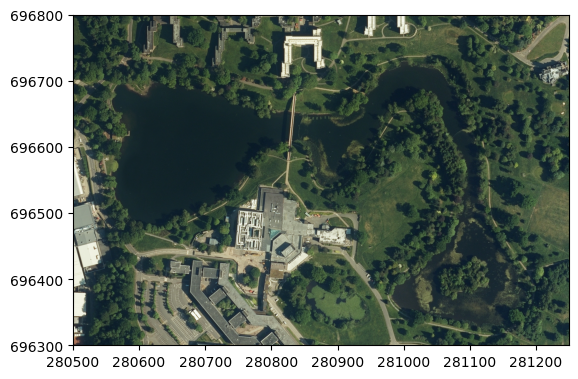

In [105]:
fig, ax = plt.subplots()

with rasterio.open('map_stuff/aerial.tif') as src:
    print(np.nanmin(src.read(1)))
    print(src.read(1).shape)
    print(src.read(2).shape)
    print(src.read(3).shape)
#     plt.imshow(src.read(26),
#               cmap='winter', vmin=0, vmax=50, 
#                extent=[lon_min, lon_max,
#                       lat_min, lat_max]
#               )
    show(src.read(), transform=src.transform,ax=ax)
    
with rasterio.open('map_stuff/aerial2.tif') as src:
    print(np.nanmin(src.read(1)))
    print(src.read(1).shape)
    print(src.read(2).shape)
    print(src.read(3).shape)
#     plt.imshow(src.read(26),
#               cmap='winter', vmin=0, vmax=50, 
#                extent=[lon_min, lon_max,
#                       lat_min, lat_max]
#               )
    show(src.read(), transform=src.transform, ax=ax)
    
    
ax.set_xlim(280500, 281250)
ax.set_ylim(696300, 696800)

In [3]:
def open_image_local(path_to_image):
    image = Image.open(path_to_image) # Open the image
    image_array = np.array(image) # Convert to a numpy array
    return image_array # Output

# Open the image from my computer
northArrow = open_image_local('map_stuff/north_arrow2.png')

In [9]:
'S2B_MSI_2023_05_15_11_45_39_T30VVH_L2W.tif'[13:15
                                            ]

'05'

In [10]:
for ax, image in zip([0, 1, 2], s2_images_acolite[:-3]):
    print(ax, image)

NameError: name 's2_images_acolite' is not defined

In [11]:
s2_images_acolite[:]

NameError: name 's2_images_acolite' is not defined

<>:80: SyntaxWarning: invalid escape sequence '\m'
<>:180: SyntaxWarning: invalid escape sequence '\m'
<>:203: SyntaxWarning: invalid escape sequence '\m'
<>:207: SyntaxWarning: invalid escape sequence '\m'
<>:80: SyntaxWarning: invalid escape sequence '\m'
<>:180: SyntaxWarning: invalid escape sequence '\m'
<>:203: SyntaxWarning: invalid escape sequence '\m'
<>:207: SyntaxWarning: invalid escape sequence '\m'
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_63342/3636222058.py:80: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.05, 0.05, 'M = {:.0f} $\mu g \: L^{{-1}}$'.format(med) ,
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_63342/3636222058.py:180: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('in situ: {:.1f} $\mu g \: L^{{-1}}$\n('.format(chl) + ins_date + ')')
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_63342/3636222058.py:203: SyntaxWarning: invalid escape sequence '\m'
  label='Chl-a Diff ($\mu g \: L^{-1}$)',)
/var

planet/
PlanetScope_24b4_2023_05_16_10_30_33_L2R.tif
PlanetScope_242b_2023_05_29_10_21_47_L2R.tif
PlanetScope_2440_2023_06_04_10_26_56_L2R.tif
Sentinel2/c2rcc_CX/
S2B_MSIL1C_20230515T114359_N0509_R123_T30VVH_20230515T121402.tif
S2A_MSIL1C_20230530T114351_N0509_R123_T30VVH_20230530T152105.tif
S2B_MSIL1C_20230604T114349_N0509_R123_T30VVH_20230604T121616.tif
Sentinel2/acolite/
S2B_MSI_2023_05_15_11_45_39_T30VVH_L2W.tif
S2A_MSI_2023_05_30_11_45_39_T30VVH_L2W.tif
S2B_MSI_2023_06_04_11_45_40_T30VVH_L2W.tif


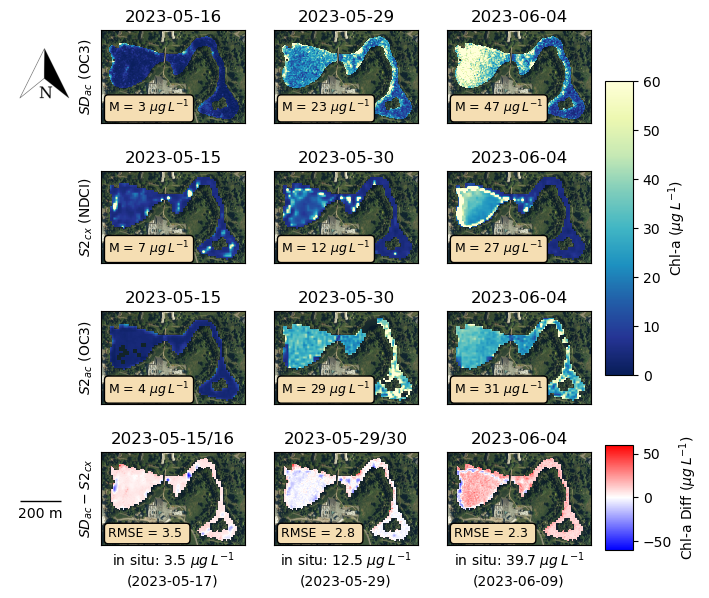

In [11]:
# note: we are working in EPSG:32630, where units are metres

fig, axs = plt.subplots(4, 3, figsize=(7,7))

# s2_images = ['S2B_MSI_2023_05_15_11_45_39_T30VVH_L2W.tif',
#              'S2A_MSI_2023_05_30_11_45_39_T30VVH_L2W.tif',
#              'S2B_MSI_2023_06_04_11_45_40_T30VVH_L2W.tif',
#              'S2A_MSI_2023_06_16_11_35_43_T30VVH_L2W.tif',
#              'S2A_MSI_2023_07_09_11_45_41_T30VVH_L2W.tif',
#              'S2A_MSI_2023_07_19_11_45_40_T30VVH_L2W.tif']

s2_images_acolite = ['S2B_MSI_2023_05_15_11_45_39_T30VVH_L2W.tif',
                     'S2A_MSI_2023_05_30_11_45_39_T30VVH_L2W.tif',
                     'S2B_MSI_2023_06_04_11_45_40_T30VVH_L2W.tif',
                     'S2A_MSI_2023_06_09_11_45_39_T30VVH_L2W.tif'
                     ]

s2_images = ['S2B_MSIL1C_20230515T114359_N0509_R123_T30VVH_20230515T121402.tif',
             'S2A_MSIL1C_20230530T114351_N0509_R123_T30VVH_20230530T152105.tif',
             'S2B_MSIL1C_20230604T114349_N0509_R123_T30VVH_20230604T121616.tif',
             'S2A_MSIL1C_20230609T114351_N0509_R123_T30VVH_20230609T151939.tif',
             'S2A_MSIL1C_20230616T113321_N0509_R080_T30VVH_20230616T164926.tif',
             'S2A_MSIL1C_20230709T114351_N0509_R123_T30VVH_20230709T152302.tif',
             'S2A_MSIL1C_20230719T114351_N0509_R123_T30VVH_20230719T152101.tif']

planet_images = ['PlanetScope_24b4_2023_05_16_10_30_33_L2R.tif',
                 'PlanetScope_242b_2023_05_29_10_21_47_L2R.tif',
                 'PlanetScope_2440_2023_06_04_10_26_56_L2R.tif',
                 'PlanetScope_2470_2023_06_09_11_08_06_L2R.tif',
                 'PlanetScope_24b9_2023_06_16_10_29_24_L2R.tif',
                 'PlanetScope_242d_2023_07_08_10_29_51_L2R.tif',
                 'PlanetScope_24b3_2023_07_21_10_34_37_L2R.tif']

axs = axs.reshape((4, 3))

VMAX = 60

S2_BAND_C2X = 2 # 1 for OC3 c2rcc_CX, previously was 28 for acolite
S2_BAND_AC = 27 # 27 for OC3, 28 for RBD

for i, sensor, band in zip([0, 1, 2], ['planet/', 'Sentinel2/c2rcc_CX/', 'Sentinel2/acolite/'],
                           [19, S2_BAND_C2X, S2_BAND_AC]):
    print(sensor)
    for i, ax, image in zip([0, 1, 2], axs[i, :], [planet_images[:-3], s2_images[:-3], s2_images_acolite[:]][i]):
        print(image)
        if sensor == 'planet/':
            title = '$SD_{ac}$ (OC3)'
            date = image[17:21] + '-' + image[22:24] + '-' + image[25:27]
        elif sensor == 'Sentinel2/c2rcc_CX/':
            title = '$S2_{cx}$ (NDCI)'
            date = image[11:15] + '-' + image[15:17] + '-' + image[17:19]
        elif sensor == 'Sentinel2/acolite/':
            title = '$S2_{ac}$ (OC3)'
            date = image[8:12] + '-' + image[13:15] + '-' + image[16:18]
            
        ax.set_title(date)
        if i == 0:
            ax.set_ylabel(title)

        with rasterio.open('map_stuff/aerial_merged_32630.tif') as src:
            show(src.read(), transform=src.transform,adjust=True, ax=ax)

        with rasterio.open('map_stuff/rasters/' + sensor + image) as src:
            # use imshow so that we have something to map the colorbar to
            c = ax.imshow(src.read(band), 
                                     cmap='YlGnBu_r', 
                                     vmin=0, 
                                     vmax=VMAX)

        with rasterio.open('map_stuff/rasters/' + sensor + image) as src:
            rast = src.read(band)
            show(rast, transform=src.transform, cmap='YlGnBu_r',
                 vmin=0, vmax=VMAX, ax=ax)
            
            # calc avg of main basin
            row, col = src.index(442850, 6222850) # is approx the loc of the bridge
            avg = np.nanmean(rast[:, :col]) # to get only basin, we just index up to the bridge loc
            med = np.nanmedian(rast[:, :col])
            props = dict(boxstyle='round', facecolor='wheat')
            ax.text(0.05, 0.05, 'M = {:.0f} $\mu g \: L^{{-1}}$'.format(med) ,
                    transform=ax.transAxes, fontsize=9,
                    verticalalignment='bottom', bbox=props)

        ax.set_xlim(442550, 443250)
        ax.set_ylim(6222550, 6223000)
        
        
        ax.tick_params(axis='x',          # changes apply to the x-axis
                       which='both',      # both major and minor ticks are affected
                       bottom=False,      # ticks along the bottom edge are off
                       top=False,         # ticks along the top edge are off
                       labelbottom=False) # labels along the bottom edge are off

        ax.tick_params(axis='y',          # changes apply to the x-axis
                       which='both',      # both major and minor ticks are affected
                       left=False,      # ticks along the bottom edge are off
                       right=False,         # ticks along the top edge are off
                       labelleft=False) # labels along the bottom edge are off
        
        scalebar = AnchoredSizeBar(ax.transData,
                                   200, '200 m', 'lower left', 
                                   pad=0.5,
                                   sep=4,
                                   color='black',
                                   frameon=False,
                                   size_vertical=1,
                                   #fontproperties=fontprops
                                  )

dates = ['2023-05-15/16', '2023-05-29/30', '2023-06-04']

insitu_chls = [3.483, 12.530, 39.744]
insitu_dates = ['2023-05-17', '2023-05-29', '2023-06-09']

axs[-1, 0].set_ylabel('$SD_{ac} - S2_{cx}$')

for ax, SD_im, S2_im, chl, ins_date, date in zip(axs[-1, :], planet_images[:-3],
                                   s2_images[:-3], insitu_chls, insitu_dates, dates):
    
    ax.set_title(date)
    
    
    with rasterio.open('map_stuff/rasters/' + 'Sentinel2/c2rcc_CX/' + S2_im)  as src_S2,\
        rasterio.open('map_stuff/rasters/' + 'planet/' + SD_im)  as src_SD:
        
        upscale_factor = 10./3.
        wind_S2 = from_bounds(442550, 6222550, 443250, 6223000, # left bottom right top
                                        src_S2.transform)
        wind_SD = from_bounds(442550, 6222550, 443250, 6223000, # left bottom right top
                                    src_SD.transform)

        old_10m_width = (443250 - 442550)/10
        old_10m_height = (6223000 - 6222550)/10

        SD = src_SD.read(19, window=wind_SD,)

        transform = rasterio.windows.transform(wind_SD, src_SD.transform)

        S2 = src_S2.read(S2_BAND_C2X, 

                        out_shape=(1, #src.count,
                                   int(old_10m_height * upscale_factor),
                                   int(old_10m_width * upscale_factor)),
                        resampling=Resampling.bilinear,
                         window=wind_S2
                       )
        
        with rasterio.open('map_stuff/aerial_merged_32630.tif') as src:
            show(src.read(), transform=src.transform,adjust=True, ax=ax)
        
        diff = SD - S2
        # get basin rmse
        row, col = src_SD.index(442850, 6222850)
        rmse = 10**RMSE_spatial(np.log10(SD[:, :col]), np.log10(S2[:, :col]))
        mapd = MAPD(np.log10(SD[:, :col]), np.log10(S2[:, :col]))
        c_diff = ax.imshow(diff, 
                             cmap='bwr', vmin=-60, vmax=60
                          )
        show(diff, transform=transform, cmap='bwr',
               #vmin=-30, vmax=30,
                 ax=ax)
        
#         ax.text(0.05, 0.05, 'RMSE = {:.1f} $\mu g \: L^{{-1}}$'.format(rmse) ,
#                     transform=ax.transAxes, fontsize=9,
#                     verticalalignment='bottom', bbox=props)
        ax.text(0.05, 0.05, 'RMSE = {:.1f} '.format(rmse) ,
                    transform=ax.transAxes, fontsize=9,
                    verticalalignment='bottom', bbox=props)
        
        ax.set_xlim(442550, 443250)
        ax.set_ylim(6222550, 6223000)
        
        
        ax.tick_params(axis='x',          # changes apply to the x-axis
                       which='both',      # both major and minor ticks are affected
                       bottom=False,      # ticks along the bottom edge are off
                       top=False,         # ticks along the top edge are off
                       labelbottom=False) # labels along the bottom edge are on?
        
        ax.set_xlabel('in situ: {:.1f} $\mu g \: L^{{-1}}$\n('.format(chl) + ins_date + ')')

        ax.tick_params(axis='y',          # changes apply to the x-axis
                       which='both',      # both major and minor ticks are affected
                       left=False,      # ticks along the bottom edge are off
                       right=False,         # ticks along the top edge are off
                       labelleft=False) # labels along the bottom edge are off
        
        scalebar = AnchoredSizeBar(ax.transData,
                                   200, '200 m', 'lower left', 
                                   pad=0.5,
                                   sep=4,
                                   color='black',
                                   frameon=False,
                                   size_vertical=1,
                                   #fontproperties=fontprops
                                  )

fig.subplots_adjust(left=0.13, right=0.83)


cbar_ax_diff = fig.add_axes([0.85, 0.12, 0.04, 0.15]) # (left, bottom, width, height)
fig.colorbar(c_diff, cax=cbar_ax_diff,
             label='Chl-a Diff ($\mu g \: L^{-1}$)',)
        

cbar_ax = fig.add_axes([0.85, 0.37, 0.04, 0.42]) # (left, bottom, width, height)
fig.colorbar(c, cax=cbar_ax, label='Chl-a ($\mu g \: L^{-1}$)')

# cbar_ax.yaxis.set_ticks_position('left')
# cbar_ax.yaxis.set_label_position('left')


scale_ax = fig.add_axes([0.0, 0.15, 0.04, 0.1]) # (left, bottom, width, height)
scale_ax.axis('off')
# scale_ax.add_artist(scalebar)

arrow_ax = fig.add_axes([0., 0.7, 0.1, 0.2]) # (left, bottom, width, height)
arrow_ax.axis('off')

scale_ax.add_artist(scalebar)



arrow_ax.imshow(northArrow,
                cmap=matplotlib.colors.ListedColormap(['black', 'none'])
)

# fig.tight_layout(rect=[0.1, 0.0, 0.83, 1]) # rect: tuple (left, bottom, right, top), default: (0, 0, 1, 1)
# plt.savefig('figures_for_paper/map_test.pdf', dpi=300)
plt.savefig('figures_for_paper/chla_maps_4by3_OC3.svg', dpi=300)


plt.show()

<>:76: SyntaxWarning: invalid escape sequence '\m'
<>:98: SyntaxWarning: invalid escape sequence '\d'
<>:99: SyntaxWarning: invalid escape sequence '\d'
<>:105: SyntaxWarning: invalid escape sequence '\m'
<>:76: SyntaxWarning: invalid escape sequence '\m'
<>:98: SyntaxWarning: invalid escape sequence '\d'
<>:99: SyntaxWarning: invalid escape sequence '\d'
<>:105: SyntaxWarning: invalid escape sequence '\m'
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/1484271326.py:76: SyntaxWarning: invalid escape sequence '\m'
  axs[i, 1].set_xlabel('Chl-a ($\mu g \: L^{-1}$)')
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/1484271326.py:98: SyntaxWarning: invalid escape sequence '\d'
  axs[i, 0].set_xlabel('Longitude ($\degree$)')
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/1484271326.py:99: SyntaxWarning: invalid escape sequence '\d'
  axs[i, 0].set_ylabel('Latitude ($\degree$)')
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_851

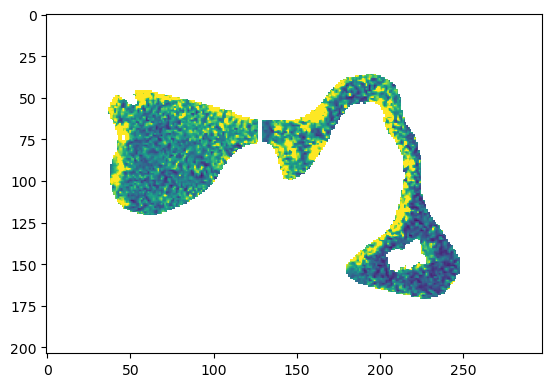

/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/1484271326.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i, 0].set_xticklabels([str(round(coord[0], 3)) for coord in new_coords])
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/1484271326.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i, 0].set_yticklabels([str(round(coord[1], 3)) for coord in new_coords])
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/1484271326.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i, 0].set_xticklabels([str(round(coord[0], 3)) for coord in new_coords])
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/1484271326.py:96: UserWarning: set_ticklabels() should only be us

19
19
19


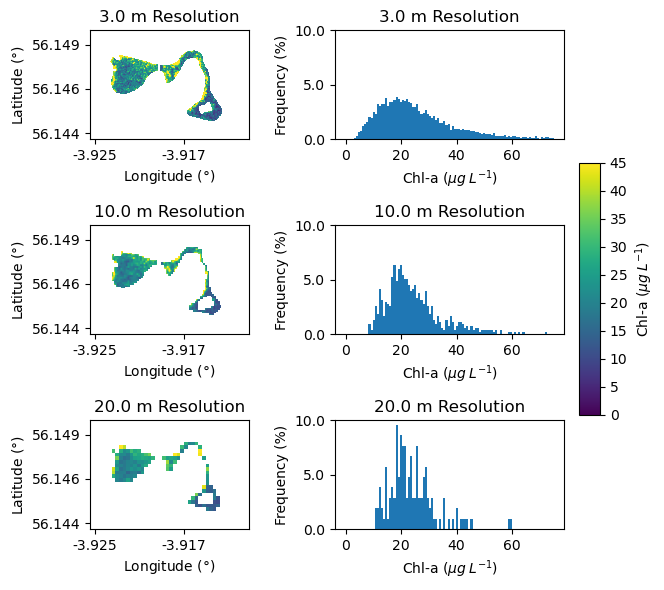

In [165]:
# quick shot at resampling analysis
# trying something similar to https://www.sciencedirect.com/science/article/pii/S1569843223004429?via%3Dihub

from matplotlib.ticker import PercentFormatter

def reproject_coords(src_crs, dst_crs, coords):
    xs = [c[0] for c in coords]
    ys = [c[1] for c in coords]
    xs, ys = fiona.transform.transform(src_crs, dst_crs, xs, ys)
    return [[x,y] for x,y in zip(xs, ys)]


src_crs = 'EPSG:32630'
dst_crs = 'EPSG:4326'

VMAX = 45
with rasterio.open('map_stuff/rasters/planet/' + planet_image) as dataset:
    c = plt.imshow(dataset.read(19), 
                     #cmap='YlGnBu_r', 
                     vmin=0, 
                     vmax=VMAX)
    
plt.show()

fig, axs = plt.subplots(3, 2, figsize=(7, 6))

planet_image = 'PlanetScope_242b_2023_05_29_10_21_47_L2R.tif'

upscale_factor = 3/10 # downsample to 10 m resolution

for i, resolution in enumerate([3., 10., 20.]):
    upscale_factor = 3./resolution

    with rasterio.open('map_stuff/rasters/planet/' + planet_image) as dataset:
        print(dataset.count)
#         c = plt.imshow(dataset.read(19), 
#                              #cmap='YlGnBu_r', 
#                              vmin=0, 
#                              vmax=VMAX)
        rast = dataset.read(19, out_shape=(
                1,
                int(dataset.height * upscale_factor),
                int(dataset.width * upscale_factor)
                ),
                resampling=Resampling.average
                           )

        # scale image transform
        transform = dataset.transform * dataset.transform.scale(
            (dataset.width / rast.shape[-1]),
            (dataset.height / rast.shape[-2])
        )

        show(rast, transform=transform,
             vmin=0, 
             vmax=VMAX, ax=axs[i, 0])

        axs[i, 1].hist(rast.flatten(), bins=100, density=True, range=(0, 75))
        axs[i, 1].set_ylim(0, 0.1)
        
#         axs[i, 0].tick_params(axis='x',          # changes apply to the x-axis
#                        which='both',      # both major and minor ticks are affected
#                        bottom=False,      # ticks along the bottom edge are off
#                        top=False,         # ticks along the top edge are off
#                        labelbottom=False) # labels along the bottom edge are on?
        

#         axs[i, 0].tick_params(axis='y',          # changes apply to the x-axis
#                        which='both',      # both major and minor ticks are affected
#                        left=False,      # ticks along the bottom edge are off
#                        right=False,         # ticks along the top edge are off
#                        labelleft=False) # labels along the bottom edge are off
        axs[i, 0].set_title(str(resolution) + ' m Resolution')
        axs[i, 1].set_title(str(resolution) + ' m Resolution')
        
        axs[i, 1].set_xlabel('Chl-a ($\mu g \: L^{-1}$)')
        axs[i, 1].set_ylabel('Frequency (%)')
        
        axs[i, 1].yaxis.set_major_formatter(PercentFormatter(1, symbol=None))
        
        



        axs[i, 0].locator_params(nbins=3)


        xs = axs[i, 0].get_xticks()
        ys = axs[i, 0].get_yticks()


        coords = [[x, y] for x, y in zip(xs, ys)]
        new_coords = reproject_coords(src_crs, dst_crs, coords)

        axs[i, 0].set_xticklabels([str(round(coord[0], 3)) for coord in new_coords])
        axs[i, 0].set_yticklabels([str(round(coord[1], 3)) for coord in new_coords])

        axs[i, 0].set_xlabel('Longitude ($\degree$)')
        axs[i, 0].set_ylabel('Latitude ($\degree$)')
        

        

cbar_ax = fig.add_axes([0.85, 0.3, 0.03, 0.42]) # (left, bottom, width, height)
fig.colorbar(c, cax=cbar_ax, label='Chl-a ($\mu g \: L^{-1}$)')

fig.tight_layout(rect=[0., 0.0, 0.85, 1]) # rect: tuple (left, bottom, right, top), default: (0, 0, 1, 1)



plt.savefig('figures_for_paper/SD_resampling_hist_2023_05_29.svg', dpi=300)



    
# with rasterio.open('map_stuff/rasters/planet/' + planet_image) as dataset:
#     print(dataset.count)
#     c = ax.imshow(dataset.read(19), 
#                          #cmap='YlGnBu_r', 
#                          vmin=0, 
#                          vmax=60)
#     rast = dataset.read(19)
        
#     show(rast, transform=dataset.transform,
#          vmin=0, 
#          vmax=60)
#     plt.show()
#     plt.hist(rast.flatten(), bins=100, density=True, range=(0, 100))
#     plt.ylim(0, 0.1)
#     plt.show()
    
        
        

In [150]:
print(coords)

[[-200000.0, -2500000.0], [0.0, 0.0], [200000.0, 2500000.0], [400000.0, 5000000.0], [600000.0, 7500000.0]]


<>:80: SyntaxWarning: invalid escape sequence '\m'
<>:180: SyntaxWarning: invalid escape sequence '\m'
<>:203: SyntaxWarning: invalid escape sequence '\m'
<>:207: SyntaxWarning: invalid escape sequence '\m'
<>:80: SyntaxWarning: invalid escape sequence '\m'
<>:180: SyntaxWarning: invalid escape sequence '\m'
<>:203: SyntaxWarning: invalid escape sequence '\m'
<>:207: SyntaxWarning: invalid escape sequence '\m'
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/2598936113.py:80: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.05, 0.05, 'M = {:.0f} $\mu g \: L^{{-1}}$'.format(med) ,
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/2598936113.py:180: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('in situ: {:.1f} $\mu g \: L^{{-1}}$\n('.format(chl) + ins_date + ')')
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/2598936113.py:203: SyntaxWarning: invalid escape sequence '\m'
  label='Chl-a Diff ($\mu g \: L^{-1}$)',)
/var

planet/
PlanetScope_24b4_2023_05_16_10_30_33_L2R.tif
PlanetScope_242b_2023_05_29_10_21_47_L2R.tif
PlanetScope_2440_2023_06_04_10_26_56_L2R.tif
Sentinel2/c2rcc_CX/
S2B_MSIL1C_20230515T114359_N0509_R123_T30VVH_20230515T121402.tif
S2A_MSIL1C_20230530T114351_N0509_R123_T30VVH_20230530T152105.tif
S2B_MSIL1C_20230604T114349_N0509_R123_T30VVH_20230604T121616.tif
Sentinel2/acolite/
S2B_MSI_2023_05_15_11_45_39_T30VVH_L2W.tif
S2A_MSI_2023_05_30_11_45_39_T30VVH_L2W.tif
S2B_MSI_2023_06_04_11_45_40_T30VVH_L2W.tif


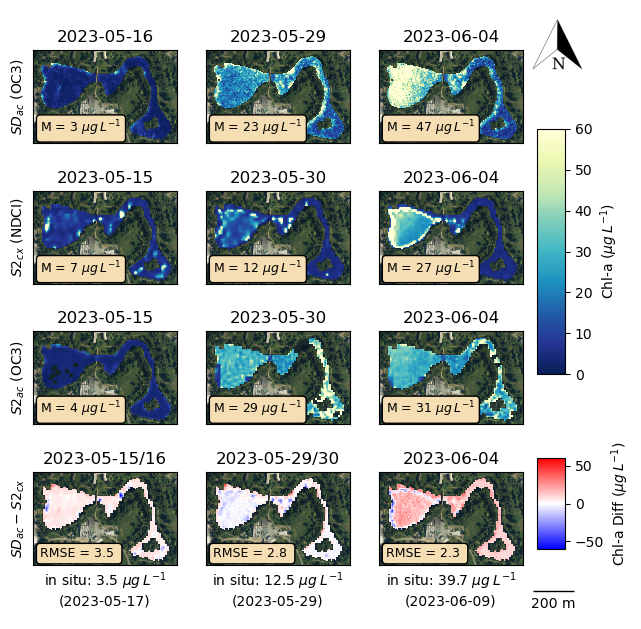

In [42]:
# note: we are working in EPSG:32630, where units are metres

fig, axs = plt.subplots(4, 3, figsize=(7,7))

# s2_images = ['S2B_MSI_2023_05_15_11_45_39_T30VVH_L2W.tif',
#              'S2A_MSI_2023_05_30_11_45_39_T30VVH_L2W.tif',
#              'S2B_MSI_2023_06_04_11_45_40_T30VVH_L2W.tif',
#              'S2A_MSI_2023_06_16_11_35_43_T30VVH_L2W.tif',
#              'S2A_MSI_2023_07_09_11_45_41_T30VVH_L2W.tif',
#              'S2A_MSI_2023_07_19_11_45_40_T30VVH_L2W.tif']

s2_images_acolite = ['S2B_MSI_2023_05_15_11_45_39_T30VVH_L2W.tif',
                     'S2A_MSI_2023_05_30_11_45_39_T30VVH_L2W.tif',
                     'S2B_MSI_2023_06_04_11_45_40_T30VVH_L2W.tif',
                     'S2A_MSI_2023_06_09_11_45_39_T30VVH_L2W.tif'
                     ]

s2_images = ['S2B_MSIL1C_20230515T114359_N0509_R123_T30VVH_20230515T121402.tif',
             'S2A_MSIL1C_20230530T114351_N0509_R123_T30VVH_20230530T152105.tif',
             'S2B_MSIL1C_20230604T114349_N0509_R123_T30VVH_20230604T121616.tif',
             'S2A_MSIL1C_20230609T114351_N0509_R123_T30VVH_20230609T151939.tif',
             'S2A_MSIL1C_20230616T113321_N0509_R080_T30VVH_20230616T164926.tif',
             'S2A_MSIL1C_20230709T114351_N0509_R123_T30VVH_20230709T152302.tif',
             'S2A_MSIL1C_20230719T114351_N0509_R123_T30VVH_20230719T152101.tif']

planet_images = ['PlanetScope_24b4_2023_05_16_10_30_33_L2R.tif',
                 'PlanetScope_242b_2023_05_29_10_21_47_L2R.tif',
                 'PlanetScope_2440_2023_06_04_10_26_56_L2R.tif',
                 'PlanetScope_2470_2023_06_09_11_08_06_L2R.tif',
                 'PlanetScope_24b9_2023_06_16_10_29_24_L2R.tif',
                 'PlanetScope_242d_2023_07_08_10_29_51_L2R.tif',
                 'PlanetScope_24b3_2023_07_21_10_34_37_L2R.tif']

axs = axs.reshape((4, 3))

VMAX = 60

S2_BAND_C2X = 2 # 1 for OC3 c2rcc_CX, previously was 28 for acolite
S2_BAND_AC = 27 # 27 for OC3, 28 for RBD

for i, sensor, band in zip([0, 1, 2], ['planet/', 'Sentinel2/c2rcc_CX/', 'Sentinel2/acolite/'],
                           [19, S2_BAND_C2X, S2_BAND_AC]):
    print(sensor)
    for i, ax, image in zip([0, 1, 2], axs[i, :], [planet_images[:-3], s2_images[:-3], s2_images_acolite[:]][i]):
        print(image)
        if sensor == 'planet/':
            title = '$SD_{ac}$ (OC3)'
            date = image[17:21] + '-' + image[22:24] + '-' + image[25:27]
        elif sensor == 'Sentinel2/c2rcc_CX/':
            title = '$S2_{cx}$ (NDCI)'
            date = image[11:15] + '-' + image[15:17] + '-' + image[17:19]
        elif sensor == 'Sentinel2/acolite/':
            title = '$S2_{ac}$ (OC3)'
            date = image[8:12] + '-' + image[13:15] + '-' + image[16:18]
            
        ax.set_title(date)
        if i == 0:
            ax.set_ylabel(title)

        with rasterio.open('map_stuff/aerial_merged_32630.tif') as src:
            show(src.read(), transform=src.transform,adjust=True, ax=ax)

        with rasterio.open('map_stuff/rasters/' + sensor + image) as src:
            # use imshow so that we have something to map the colorbar to
            c = ax.imshow(src.read(band), 
                                     cmap='YlGnBu_r', 
                                     vmin=0, 
                                     vmax=VMAX)

        with rasterio.open('map_stuff/rasters/' + sensor + image) as src:
            rast = src.read(band)
            show(rast, transform=src.transform, cmap='YlGnBu_r',
                 vmin=0, vmax=VMAX, ax=ax)
            
            # calc avg of main basin
            row, col = src.index(442850, 6222850) # is approx the loc of the bridge
            avg = np.nanmean(rast[:, :col]) # to get only basin, we just index up to the bridge loc
            med = np.nanmedian(rast[:, :col])
            props = dict(boxstyle='round', facecolor='wheat')
            ax.text(0.05, 0.05, 'M = {:.0f} $\mu g \: L^{{-1}}$'.format(med) ,
                    transform=ax.transAxes, fontsize=9,
                    verticalalignment='bottom', bbox=props)

        ax.set_xlim(442550, 443250)
        ax.set_ylim(6222550, 6223000)
        
        
        ax.tick_params(axis='x',          # changes apply to the x-axis
                       which='both',      # both major and minor ticks are affected
                       bottom=False,      # ticks along the bottom edge are off
                       top=False,         # ticks along the top edge are off
                       labelbottom=False) # labels along the bottom edge are off

        ax.tick_params(axis='y',          # changes apply to the x-axis
                       which='both',      # both major and minor ticks are affected
                       left=False,      # ticks along the bottom edge are off
                       right=False,         # ticks along the top edge are off
                       labelleft=False) # labels along the bottom edge are off
        
        scalebar = AnchoredSizeBar(ax.transData,
                                   200, '200 m', 'lower left', 
                                   pad=0.5,
                                   sep=4,
                                   color='black',
                                   frameon=False,
                                   size_vertical=1,
                                   #fontproperties=fontprops
                                  )

dates = ['2023-05-15/16', '2023-05-29/30', '2023-06-04']

insitu_chls = [3.483, 12.530, 39.744]
insitu_dates = ['2023-05-17', '2023-05-29', '2023-06-09']

axs[-1, 0].set_ylabel('$SD_{ac} - S2_{cx}$')

for ax, SD_im, S2_im, chl, ins_date, date in zip(axs[-1, :], planet_images[:-3],
                                   s2_images[:-3], insitu_chls, insitu_dates, dates):
    
    ax.set_title(date)
    
    
    with rasterio.open('map_stuff/rasters/' + 'Sentinel2/c2rcc_CX/' + S2_im)  as src_S2,\
        rasterio.open('map_stuff/rasters/' + 'planet/' + SD_im)  as src_SD:
        
        upscale_factor = 10./3.
        wind_S2 = from_bounds(442550, 6222550, 443250, 6223000, # left bottom right top
                                        src_S2.transform)
        wind_SD = from_bounds(442550, 6222550, 443250, 6223000, # left bottom right top
                                    src_SD.transform)

        old_10m_width = (443250 - 442550)/10
        old_10m_height = (6223000 - 6222550)/10

        SD = src_SD.read(19, window=wind_SD,)

        transform = rasterio.windows.transform(wind_SD, src_SD.transform)

        S2 = src_S2.read(S2_BAND_C2X, 

                        out_shape=(1, #src.count,
                                   int(old_10m_height * upscale_factor),
                                   int(old_10m_width * upscale_factor)),
                        resampling=Resampling.bilinear,
                         window=wind_S2
                       )
        
        with rasterio.open('map_stuff/aerial_merged_32630.tif') as src:
            show(src.read(), transform=src.transform,adjust=True, ax=ax)
        
        diff = SD - S2
        # get basin rmse
        row, col = src_SD.index(442850, 6222850)
        rmse = 10**RMSE_spatial(np.log10(SD[:, :col]), np.log10(S2[:, :col]))
        mapd = MAPD(np.log10(SD[:, :col]), np.log10(S2[:, :col]))
        c_diff = ax.imshow(diff, 
                             cmap='bwr', vmin=-60, vmax=60
                          )
        show(diff, transform=transform, cmap='bwr',
               #vmin=-30, vmax=30,
                 ax=ax)
        
#         ax.text(0.05, 0.05, 'RMSE = {:.1f} $\mu g \: L^{{-1}}$'.format(rmse) ,
#                     transform=ax.transAxes, fontsize=9,
#                     verticalalignment='bottom', bbox=props)
        ax.text(0.05, 0.05, 'RMSE = {:.1f} '.format(rmse) ,
                    transform=ax.transAxes, fontsize=9,
                    verticalalignment='bottom', bbox=props)
        
        ax.set_xlim(442550, 443250)
        ax.set_ylim(6222550, 6223000)
        
        
        ax.tick_params(axis='x',          # changes apply to the x-axis
                       which='both',      # both major and minor ticks are affected
                       bottom=False,      # ticks along the bottom edge are off
                       top=False,         # ticks along the top edge are off
                       labelbottom=False) # labels along the bottom edge are on?
        
        ax.set_xlabel('in situ: {:.1f} $\mu g \: L^{{-1}}$\n('.format(chl) + ins_date + ')')

        ax.tick_params(axis='y',          # changes apply to the x-axis
                       which='both',      # both major and minor ticks are affected
                       left=False,      # ticks along the bottom edge are off
                       right=False,         # ticks along the top edge are off
                       labelleft=False) # labels along the bottom edge are off
        
        scalebar = AnchoredSizeBar(ax.transData,
                                   200, '200 m', 'lower left', 
                                   pad=0.5,
                                   sep=4,
                                   color='black',
                                   frameon=False,
                                   size_vertical=1,
                                   #fontproperties=fontprops
                                  )

fig.subplots_adjust(left=0.13, right=0.83)


cbar_ax_diff = fig.add_axes([0.85, 0.15, 0.04, 0.13]) # (left, bottom, width, height)
fig.colorbar(c_diff, cax=cbar_ax_diff,
             label='Chl-a Diff ($\mu g \: L^{-1}$)',)
        

cbar_ax = fig.add_axes([0.85, 0.4, 0.04, 0.35]) # (left, bottom, width, height)
fig.colorbar(c, cax=cbar_ax, label='Chl-a ($\mu g \: L^{-1}$)')

# cbar_ax.yaxis.set_ticks_position('left')
# cbar_ax.yaxis.set_label_position('left')


scale_ax = fig.add_axes([0.83, 0.05, 0.04, 0.1]) # (left, bottom, width, height)
scale_ax.axis('off')
# scale_ax.add_artist(scalebar)

arrow_ax = fig.add_axes([0.83, 0.77, 0.1, 0.2]) # (left, bottom, width, height)
arrow_ax.axis('off')

scale_ax.add_artist(scalebar)



arrow_ax.imshow(northArrow,
                cmap=matplotlib.colors.ListedColormap(['black', 'none'])
)

# fig.tight_layout(rect=[0.1, 0.0, 0.83, 1]) # rect: tuple (left, bottom, right, top), default: (0, 0, 1, 1)
# plt.savefig('figures_for_paper/map_test.pdf', dpi=300)
plt.savefig('figures_for_paper/chla_maps_4by3_OC3.svg', dpi=300)


plt.show()

In [61]:
np.sum(~np.isnan(SD[:, :col]) & ~np.isnan(S2[:, :col]))

4933

In [96]:
RMSE_spatial(np.log10(S2[:, :col]), np.log10(SD[:, :col]))

0.3730861264261244

In [72]:
10**(np.sqrt(np.nanmean((np.log10(S2[:, :col]) - np.log10(SD[:, :col]))**2)))-1

2919.4761094072956

In [64]:
np.nanmedian(np.abs(diff[:, :col]))

17.802243678866336

In [20]:
# NEED TO DO SOME WORK ON THE RMSE calc.... my new coeffs have made it really bad?...

76 125
(204, 298)


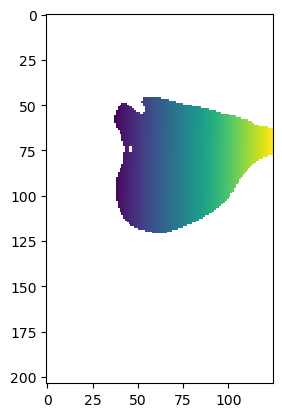

In [47]:
S2_im = 'Sentinel2/c2rcc_CX/S2A_MSIL1C_20230530T114351_N0509_R123_T30VVH_20230530T152105.tif'
SD_im = 'planet/PlanetScope_242b_2023_05_29_10_21_47_L2R.tif'

with rasterio.open('map_stuff/rasters/' + S2_im)  as src_S2,\
    rasterio.open('map_stuff/rasters/' + SD_im)  as src_SD:
    SD = src_SD.read(1)
    row, col = src_SD.index(442850, 6222850)
    print(row, col)
    print(SD.shape)
    show(SD[:, :col])#, transform=src_SD.transform)
    

In [52]:
avg = 1.
print('$$\mu_{{W}}$$ = {:.0f} ($\mu g \: L^{{-1}}$)'.format(avg))

$$\mu_{W}$$ = 1 ($\mu g \: L^{-1}$)


<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_45821/194203491.py:2: SyntaxWarning: invalid escape sequence '\m'
  print('$$\mu_{{W}}$$ = {:.0f} ($\mu g \: L^{{-1}}$)'.format(avg))


# update 18 Jun 2024

- I've successully got the c2rcc_CX S2 data mapped 

Next steps:
- make the above plot publication ready: consider fewer images (maybe more like the presentation fig?) - DONE(ish)
- make a chl-a diff between S2 and SD - DONE
- add loch avg chl-a to spatial plots. - DONE
- could also use the loch avg chla for the long time series plot? - DONE below with SEPA and bloomin algae data
- cross correlation between S2 and SD (issue is that I'm missing some S2 images?)

# update 19 Jun
- added chl-a diff: ISSUE is that this really highlights how different the sentinel 2 chl-a data is from the Planet... 
    - adding lake avg might also be interesting
    - 

# lake avg time series

ModuleNotFoundError: No module named 'seaborn'

In [104]:
pd.to_datetime('map_stuff/rasters/planet/PlanetScope_2413_2022_01_20_11_22_58_L2R.tif'[42:52], 
               format="%Y_%m_%d").date()

datetime.date(2022, 1, 20)

In [245]:
glob.glob('planetData/full_SR/9c146ad9-20eb-4407-83b5-7ad963549f7c/PSScene/' +\
            file[42:46] + file[47:49] + file[50:52] + '_' + file[53:55] +\
            file[56:58] + file[59:61] + '*' + 'udm2_clip.tif')[0]

'planetData/full_SR/9c146ad9-20eb-4407-83b5-7ad963549f7c/PSScene/20220710_110152_14_247e_3B_udm2_clip.tif'

In [277]:
msk

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       ...,
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [297]:
((np.isnan(rast[:, :col]) | msk) == False).sum()

4744

In [335]:
np.ma.masked_array(rast[:, :col], ~msk)

masked_array(
  data=[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., --, --, --],
        [nan, nan, nan, ..., --, --, --],
        ...,
        [nan, nan, nan, ..., --, --, --],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],
  mask=[[False, False, False, ..., False, False, False],
        [False, False, False, ...,  True,  True,  True],
        [False, False, False, ...,  True,  True,  True],
        ...,
        [False, False, False, ...,  True,  True,  True],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],
  fill_value=1e+20)

In [296]:
12387 ==True

False

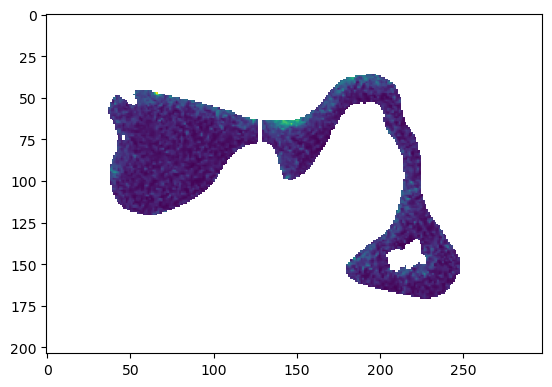

In [371]:
plt.imshow(np.ma.masked_array(rast, np.isnan(rast) | (rast_clear==0) ))

In [372]:
np.ma.masked_array(rast, np.isnan(rast) | (rast_clear==0) ).mean()

5.461937566607973

In [363]:
np.unique(rast_clear)

array([0, 1], dtype=uint8)

In [13]:
dates =[]
avgs = []

for i, file in enumerate(glob.glob("map_stuff/rasters/planet/*L2R.tif")):
    
    udm_file_name = glob.glob('planetData/full_SR/9c146ad9-20eb-4407-83b5-7ad963549f7c/PSScene/' +\
                                file[42:46] + file[47:49] + file[50:52] + '_' + file[53:55] +\
                                file[56:58] + file[59:61] + '*' + 'udm2_clip.tif')[0]
#     print(i, file)
    with rasterio.open(file) as src, rasterio.open(udm_file_name) as udm:
        rast = src.read(19)
        rast_cloud = udm.read(6) # cloud band
        rast_heavy_haze = udm.read(5)
        row, col = src.index(442850, 6222850) # is approx the loc of the bridge
        msk = (rast_heavy_haze[:, :col] == 1) | (rast_cloud[:, :col] == 1) | np.isnan(rast[:, :col])
        avg = np.ma.median(np.ma.masked_array(rast[:, :col], msk, fill_value=np.nan))

        # if we have more than 20 % cloud cover over the AOI then don't use this image
        # first need to work out number of valid water pixels:
        n_val_water = len(rast[:, :col].flatten()) - np.isnan(rast[:, :col]).sum()
        n_valid = ((np.isnan(rast[:, :col]) | msk) == False).sum()
        pct_good = n_valid/n_val_water
        print(pct_good)
        if pct_good < 0.8:
            avg = np.nan
        # to get only basin, we just index up to the bridge loc
        date = pd.to_datetime(file[42:52], format="%Y_%m_%d").date()
        dates.append(date)
        avgs.append(avg)

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.9793423271500843
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.9527824620573356
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.

In [49]:
# quick attempt to look at the difference in chl-a between the sampling loc and AOI

# bottom left corner of AOI
loc_AOI = (442634.8257971745 - 15, 6222824.910507713 - 15)


# sampling location:
loc_sample = (442634.8257971745-20, 6222824.910507713+25)

dates =[]
avgs_sample = []
avgs_AOI = []


for i, file in enumerate(glob.glob("map_stuff/rasters/planet/*L2R.tif")):
    
    udm_file_name = glob.glob('planetData/full_SR/9c146ad9-20eb-4407-83b5-7ad963549f7c/PSScene/' +\
                                file[42:46] + file[47:49] + file[50:52] + '_' + file[53:55] +\
                                file[56:58] + file[59:61] + '*' + 'udm2_clip.tif')[0]
#     print(i, file)
    with rasterio.open(file) as src, rasterio.open(udm_file_name) as udm:
        rast = src.read(19)
        rast_cloud = udm.read(6) # cloud band
        rast_heavy_haze = udm.read(5)
        
        # get chl-a at sample loc
        
        row, col = src.index(*loc_sample)
        msk = (rast_heavy_haze[row, col] == 1) | (rast_cloud[row, col] == 1) | np.isnan(rast[row, col])
        sample_avg = np.ma.median(np.ma.masked_array(rast[row, col], msk, fill_value=np.nan))
        
        # get chl-a at AOI

        row, col = src.index(*loc_AOI)
        msk = (rast_heavy_haze[row-10:row,
                               col:col+10] == 1) | (rast_cloud[row-10:row,
                                                               col:col+10] == 1) | np.isnan(rast[row-10:row,
                                                                                                 col:col+10])
        AOI_avg = np.ma.median(np.ma.masked_array(rast[row-10:row,
                                                          col:col+10], msk, fill_value=np.nan))

        # if we have more than 20 % cloud cover over the AOI then don't use this image
        # first need to work out number of valid water pixels:
        date = pd.to_datetime(file[42:52], format="%Y_%m_%d").date()
        dates.append(date)
        avgs_sample.append(sample_avg)
        avgs_AOI.append(AOI_avg)

        

/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/4064126641.py:1: UserWarning: Warning: converting a masked element to nan.
  plt.hist(np.array(avgs_AOI) - np.array(avgs_sample), bins=60)
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/4064126641.py:6: UserWarning: Warning: converting a masked element to nan.
  np.nanstd(np.array(avgs_AOI) - np.array(avgs_sample))


15.52459020940079

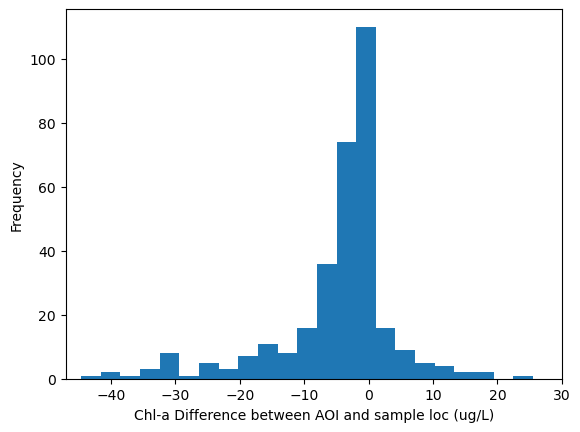

In [72]:
plt.hist(np.array(avgs_AOI) - np.array(avgs_sample), bins=60)
plt.xlim(-47, 30)
plt.ylabel('Frequency')
plt.xlabel('Chl-a Difference between AOI and sample loc (ug/L)')

np.nanstd(np.array(avgs_AOI) - np.array(avgs_sample))

In [14]:
df_avgs = pd.DataFrame(data={'Date':dates, 'Chla':avgs})
df_avgs.Date = pd.to_datetime(df_avgs.Date)
df_avgs = df_avgs.groupby('Date').median().reset_index()
df_avgs.sort_values('Date', inplace=True)

In [15]:
df_avgs['SEPA_bloom'] = False
df_avgs['BA_bloom'] = False

In [16]:
df_avgs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        191 non-null    datetime64[ns]
 1   Chla        191 non-null    float64       
 2   SEPA_bloom  191 non-null    bool          
 3   BA_bloom    191 non-null    bool          
dtypes: bool(2), datetime64[ns](1), float64(1)
memory usage: 3.5 KB


In [17]:
'map_stuff/rasters/Sentinel2/c2rcc_CX_21_24/S2B_MSIL1C_20211022T114349_N0500_R123_T30VVH_20230106T141427.tif'[43:]

'S2B_MSIL1C_20211022T114349_N0500_R123_T30VVH_20230106T141427.tif'

In [18]:
flag_mask  = 0b1111111111 + 2048 + 4096 + 65536 + 1048576 #+ 524288
flag_mask

1121279

# hopefully this code below works! 
- but will only work once we've got the full idepix output sorted.
- need to wait overnight! 

so, first re-run the code which converts the idpix nc files to tifs (maybe want to change the dir of the idpix shit too so that its not weird!)
then try running this code below:
hopefully we get some real good stuff. 

In [19]:
# get S2 data:

dates =[]
avgs = []

for i, file in enumerate(glob.glob("map_stuff/rasters/Sentinel2/c2rcc_CX_21_24/*.tif")):
#     print(i, file)
    with rasterio.open(file) as src, rasterio.open('map_stuff/rasters/Sentinel2/idepix/' + file[43:]) as src_idpx:
#         print(i)
        rast = src.read(1)
        rast_idpx = src_idpx.read(1)
        row, col = src.index(442850, 6222850) # is approx the loc of the bridge
        msk = (rast_idpx[:, :col] & flag_mask) != 0
#         print(np.unique(msk))
        avg = np.ma.median(np.ma.masked_array(rast[:, :col], msk, fill_value=np.nan)) # to get only basin, we just index up to the bridge loc
        # if we have more than 20% cloud cover over the AOI then don't use this image
        # first need to work out number of valid water pixels:
        n_val_water = len(rast[:, :col].flatten()) - np.isnan(rast[:, :col]).sum()
        n_valid = (msk == False).sum()
        pct_good = n_valid/n_val_water
        if pct_good < 0.8:
            avg = np.nan
        # note that S2 filename format has 2 dates:
        # - first date is the aquisition date, and the 2nd is the generation time
        # in some cases the generation time is years after the aquisition! 
        date = pd.to_datetime(file[54:62], format="%Y%m%d").date()
        dates.append(date)
        avgs.append(avg)

In [20]:
df_avgs_S2 = pd.DataFrame(data={'Date':dates, 'Chla':np.array(avgs)})
df_avgs_S2.Date = pd.to_datetime(df_avgs_S2.Date)
df_avgs_S2 = df_avgs_S2.groupby('Date').median().reset_index()
df_avgs_S2.sort_values('Date', inplace=True)

In [21]:
df_avgs_S2

,Date,Chla
0,2021-01-02,8.365466
1,2021-01-05,NaN
2,2021-01-07,NaN
3,2021-01-10,NaN
4,2021-01-12,NaN
...,...,...
479,2024-06-28,NaN
480,2024-06-30,NaN
481,2024-07-03,NaN
482,2024-07-10,NaN


In [22]:
df_avgs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        191 non-null    datetime64[ns]
 1   Chla        191 non-null    float64       
 2   SEPA_bloom  191 non-null    bool          
 3   BA_bloom    191 non-null    bool          
dtypes: bool(2), datetime64[ns](1), float64(1)
memory usage: 3.5 KB


In [23]:
df_avgs_S2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484 entries, 0 to 483
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    484 non-null    datetime64[ns]
 1   Chla    91 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 7.7 KB


In [24]:
SEPA_blooms = pd.DataFrame({'Date':['15-06-2021', '17-08-2021', '02-05-2022',
                                    '22-06-2022', '26-10-2022'],
                            'Bloom':[False, False, True, False, False,]
                            })

BA_blooms = pd.DataFrame({'Date':['28-04-2022', '10-05-2022', '15-08-2022', '18-08-2022',
                                     '01-06-2023'],
                            'Bloom':[True, True, True, True, True]})

In [25]:
SEPA_blooms.Date = pd.to_datetime(SEPA_blooms.Date, format='%d-%m-%Y')
BA_blooms.Date = pd.to_datetime(BA_blooms.Date, format='%d-%m-%Y')

In [26]:
m_years = mdates.YearLocator()   # every year
m_months = mdates.MonthLocator()  # every month
monthsFmt = mdates.DateFormatter('%b \'%y')

<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_63342/506969524.py:28: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Chl-a ($\mu g \: L^{-1}$)')


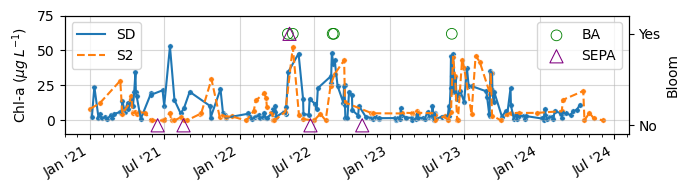

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(7, 2.))
sns.lineplot(data=df_avgs[df_avgs.Date.dt.year!=2020],
             x='Date', y='Chla', ax=ax,
                     color=sns.color_palette()[0], #linestyle='--',
                     legend=False,
                       )
sns.scatterplot(data=df_avgs[df_avgs.Date.dt.year!=2020],
             x='Date', y='Chla', ax=ax,
                     color=sns.color_palette()[0],
                s=15,
                       )

sns.lineplot(data=df_avgs_S2[df_avgs_S2.Date.dt.year!=2020],
             x='Date', y='Chla', ax=ax,
                     color=sns.color_palette()[1], linestyle='--',
                     legend=False,
                       )

sns.scatterplot(data=df_avgs_S2[df_avgs_S2.Date.dt.year!=2020],
             x='Date', y='Chla', ax=ax,
                     color=sns.color_palette()[1],
                s=15,
                       )
ax.grid(alpha=0.5)
ax.xaxis.set_major_formatter(monthsFmt)
ax.xaxis.set_minor_locator(m_months)
fig.autofmt_xdate()
ax.set_ylabel('Chl-a ($\mu g \: L^{-1}$)')
ax.set_xlabel('')
ax.set_ylim(-10., 75)

ax_bloom = ax.twinx()

sns.scatterplot(data=BA_blooms, x='Date', y='Bloom', facecolors='none', edgecolors='green',
                ax=ax_bloom, marker='o', #color='green',
                label="BA", #alpha=0.7,
                s=60)

sns.scatterplot(data=SEPA_blooms, x='Date', y='Bloom', facecolors='none', edgecolors='purple',
                ax=ax_bloom, marker='^', #color='purple',
                label='SEPA', #alpha=0.8,
                s=90)



ax_bloom.set_yticks([0, 1])
ax_bloom.set_yticklabels(['No', 'Yes'])
ax_bloom.set_ylim(-0.1, 1.2)

ax_bloom.legend(loc='upper right')
ax.legend(ax.lines, ['SD', 'S2'], loc='upper left')

plt.tight_layout()
plt.savefig('figures_for_paper/SD_chla_timeseries_SEPA_BA_MEDIAN.svg', dpi=300)
    


plt.show()


## Right now, the S2 data is super noisy because we haven't removed clouds! 
- need to use IDPIX for this I think.
- BUT preliminary F1 score calcs are looking pretty good. Basically, S2 data looks like it generally gets the peaks but they are lower magnitude
    - ultimately, this makes this data less useful for bloom classification as setting the threshold at a low point will in reality lead to many false positives 
    - can say that 
    
- when I redo with IDPIX, I should make sure that the numbers I've got for the F1 calc still look good.

QUESTION: have I removed clouds from superdoves data?

[ 0  5 10 15 20 25 30 35 40 45 50 55]


<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_12974/1701310727.py:20: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('Bloom threshold ($\mu g \: L^{-1}$)')


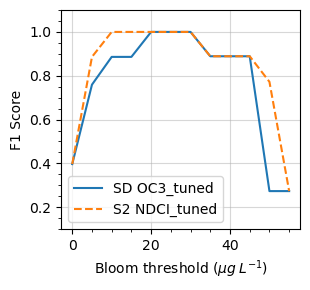

In [435]:
total_blooms = np.array([0, 0, 1, 1, 1, 0, 1, 0, 1])
SD_blooms = np.array([20, 6, 35, 49, 49, 4, 48, 5, 48])
S2_blooms = np.array([1, 3, 52, 52, 52, 2, 32, 10, 47])
SD_blooms > 26.78459999999998
scores = []
thresholds = np.arange(0, 60, 5)
print(thresholds)
for thresh in thresholds:
    scores.append(f1_score(total_blooms, SD_blooms > thresh, average='weighted'), )

scoresS2 = []
    
for thresh in thresholds:
    scoresS2.append(f1_score(total_blooms, S2_blooms > thresh, average='weighted'), )
    
fig, ax = plt.subplots(1, 1, figsize=(3.2, 3))
ax.plot(thresholds, scores, label='SD OC3_tuned')
ax.plot(thresholds, scoresS2, '--', label='S2 NDCI_tuned')

ax.set_xlabel('Bloom threshold ($\mu g \: L^{-1}$)')
ax.set_ylabel('F1 Score')
ax.minorticks_on()
ax.grid(alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()

ax.set_ylim(0.1, 1.1)
plt.savefig('figures_for_paper/SD_SEPA_BA_F1_score_median.svg', dpi=300)
plt.show()

[ 0  5 10 15 20 25 30 35 40 45 50 55]


<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_63342/4080466903.py:20: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('Bloom threshold ($\mu g \: L^{-1}$)')


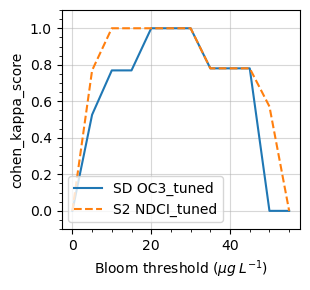

In [42]:
total_blooms = np.array([0, 0, 1, 1, 1, 0, 1, 0, 1])
SD_blooms = np.array([20, 6, 35, 49, 49, 4, 48, 5, 48])
S2_blooms = np.array([1, 3, 52, 52, 52, 2, 32, 10, 47])
SD_blooms > 26.78459999999998
scores = []
thresholds = np.arange(0, 60, 5)
print(thresholds)
for thresh in thresholds:
    scores.append(cohen_kappa_score(total_blooms, SD_blooms > thresh), )

scoresS2 = []
    
for thresh in thresholds:
    scoresS2.append(cohen_kappa_score(total_blooms, S2_blooms > thresh), )
    
fig, ax = plt.subplots(1, 1, figsize=(3.2, 3))
ax.plot(thresholds, scores, label='SD OC3_tuned')
ax.plot(thresholds, scoresS2, '--', label='S2 NDCI_tuned')

ax.set_xlabel('Bloom threshold ($\mu g \: L^{-1}$)')
ax.set_ylabel('cohen_kappa_score')
ax.minorticks_on()
ax.grid(alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()

ax.set_ylim(-0.1, 1.1)
# plt.savefig('figures_for_paper/SD_SEPA_BA_F1_score_median.svg', dpi=300)
plt.show()

In [441]:
scores

[0.39682539682539686,
 0.7592592592592593,
 0.886002886002886,
 0.886002886002886,
 1.0,
 1.0,
 1.0,
 0.8888888888888888,
 0.8888888888888888,
 0.8888888888888888,
 0.27350427350427353,
 0.27350427350427353]

In [21]:
from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay

[0.  0.2 0.4 0.8 1.  1.  1.  1.  1. ] 
 [0.   0.   0.   0.   0.   0.25 0.5  0.75 1.  ] 
 [inf 52. 51. 50. 39. 25.  7.  4.  3.]


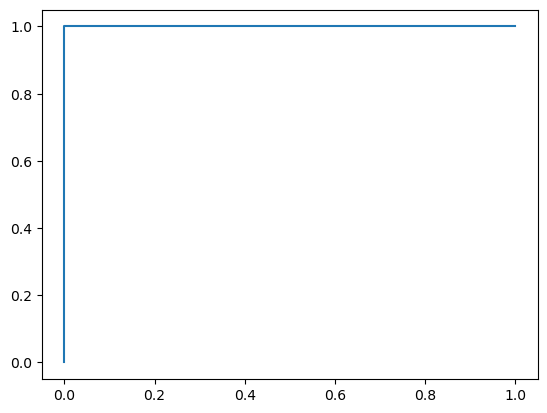

In [33]:
fpr, tpr, threshs = roc_curve(total_blooms, SD_blooms, drop_intermediate=False)
print(tpr, '\n', fpr,'\n', threshs)
plt.plot(fpr, tpr)

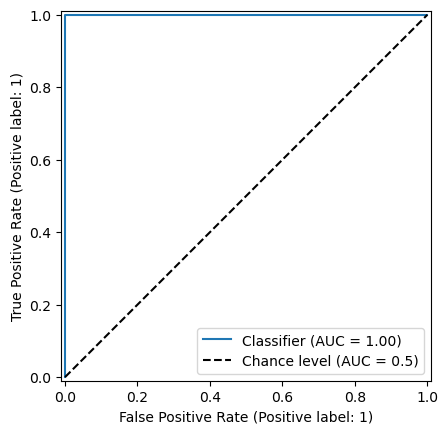

In [32]:
RocCurveDisplay.from_predictions(total_blooms, SD_blooms/100,
                                 drop_intermediate=False, plot_chance_level=True)

## interestingly, the ROC curve for this data is perfect!
- this is because all records of blooms have a higher chl-a level than records of no blooms in a consistent way
- this means with the appropriate threshold we can correctly identify all blooms without any False positives 
- we know this from the F1 score curve too! - but the F1 score curve gives more info as we can see how adjusting the threshold is key to obtaining good performance
- I think presenting a perfect ROC curve is a bit misleading - possibly if the S2 data had some FPs then that would be an interesting demo, but we learn more about what is happening from the F1 score situation.
- the reality is that the threshold would be set according to some health/safety guidance: it doesn't make sense to define a bloom as 'whatever our satellite is capable of distinguishing as different from low levels of chl-a'
- so really the ROC curve isn't the right tool for this job! 

## here I've taken data from SEPA and bloomin' algae (BA)

- the SEPA bloom YES/NO is based on obtaining >100000 cells/ml
- the Bloomin' algae bloom YES/NO is based on records which were submitted to the app and subsequently verified by UKCEH. 
    - there were no 'incorrectly' identified blooms, and only 1 'plausible' bloom which was recorded on the 2nd of May 2022, which was ommitted from the plot.

(0.0, 100.0)

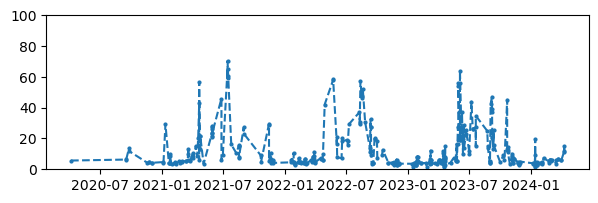

In [10]:
fig, ax = plt.subplots(figsize=(7, 2))
df_avgs = pd.DataFrame(data={'Date':dates, 'Chla':avgs})
df_avgs.sort_values('Date', inplace=True)
df_avgs
ax.plot(df_avgs.Date, df_avgs.Chla, marker='o', markersize=2, linestyle='--')
ax.set_ylim(0, 100)


# diff'ing S2 and SD

(150, 233)
(150, 233)


<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_33910/1548778492.py:54: SyntaxWarning: invalid escape sequence '\m'
  label='Chl-a Diff ($\mu g \: L^{-1}$)',)


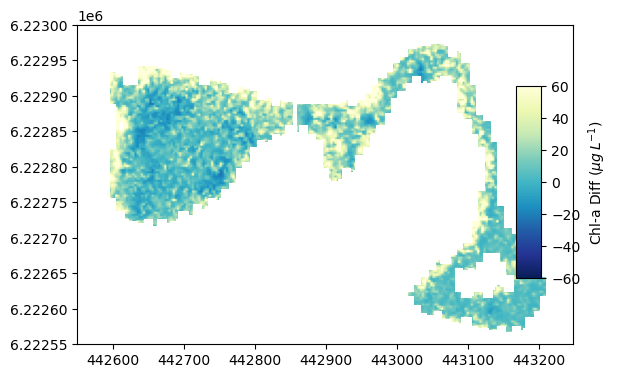

In [220]:
# start with 2 images:

S2_im = 'Sentinel2/c2rcc_CX/S2A_MSIL1C_20230530T114351_N0509_R123_T30VVH_20230530T152105.tif'
SD_im = 'planet/PlanetScope_242b_2023_05_29_10_21_47_L2R.tif'

upscale_factor = 10./3.

fig, ax = plt.subplots()





with rasterio.open('map_stuff/rasters/' + S2_im)  as src_S2,\
    rasterio.open('map_stuff/rasters/' + SD_im)  as src_SD:
    
    wind_S2 = from_bounds(442550, 6222550, 443250, 6223000, # left bottom right top
                                    src_S2.transform)
    wind_SD = from_bounds(442550, 6222550, 443250, 6223000, # left bottom right top
                                src_SD.transform)

    old_10m_width = (443250 - 442550)/10
    old_10m_height = (6223000 - 6222550)/10
    
    SD = src_SD.read(19, window=wind_SD,)
    
    transform = rasterio.windows.transform(wind, src_SD.transform)

    S2 = src_S2.read(1, 

                    out_shape=(1, #src.count,
                               int(old_10m_height * upscale_factor),
                               int(old_10m_width * upscale_factor)),
                    resampling=Resampling.bilinear,
                     window=wind_S2
                   )
    #scale image transform
#     transform = rasterio.windows.transform(wind,
#                                            src.transform) * src.transform.scale(
#                                                                     (old_10m_width / rast.shape[-1]),
#                                                                     (old_10m_height / rast.shape[-2]))
#     show(SD, transform=transform, cmap='YlGnBu_r',
#              vmin=0, vmax=VMAX, ax=ax)
#     show(S2, transform=transform, cmap='YlGnBu_r',
#              vmin=0, vmax=VMAX, ax=ax)

    c = ax.imshow(SD-S2, 
                  cmap='YlGnBu_r', vmin=-60, vmax=60)
    show(SD-S2, transform=transform, cmap='YlGnBu_r',
           vmin=-60, vmax=60,
     ax=ax)
    cbar_ax = fig.add_axes([0.81, 0.3, 0.04, 0.4]) # (left, bottom, width, height)
    fig.colorbar(c, cax=cbar_ax,
                 label='Chl-a Diff ($\mu g \: L^{-1}$)',)    
    
    
    print(SD.shape)
    print(S2.shape)

        


    

# with rasterio.open('map_stuff/rasters/' + SD_im) as src:   
#     wind = from_bounds(442550, 6222550, 443250, 6223000, # left bottom right top
#                                            src.transform)
    
#     print(transform)
#     show(rast, transform=transform, cmap='YlGnBu_r',
#                  vmin=0, vmax=VMAX, ax=ax)
    
#     print(rast.shape)
#     print(src.width)
#     print(src.height)

# ax.set_xlim(442450, 442450+100)

# # first need to resample and clip to same extent

# with rasterio.open("example.tif") as dataset:

#     # resample data to target shape
#     data = dataset.read(
#         out_shape=(
#             dataset.count,
#             int(dataset.height * upscale_factor),
#             int(dataset.width * upscale_factor)
#         ),
#         resampling=Resampling.bilinear
#     )

#     # scale image transform
#     transform = dataset.transform * dataset.transform.scale(
#         (dataset.width / data.shape[-1]),
#         (dataset.height / data.shape[-2])
#     )

In [202]:
old_10m_height * upscale_factor

150.0

<>:86: SyntaxWarning: invalid escape sequence '\m'
<>:86: SyntaxWarning: invalid escape sequence '\m'
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_33910/1213405275.py:86: SyntaxWarning: invalid escape sequence '\m'
  fig.colorbar(c, cax=cbar_ax, label='Chl-a ($\mu g \: L^{-1}$)')
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_33910/1213405275.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.0, 0.0, 0.8, 1]) # rect: tuple (left, bottom, right, top), default: (0, 0, 1, 1)


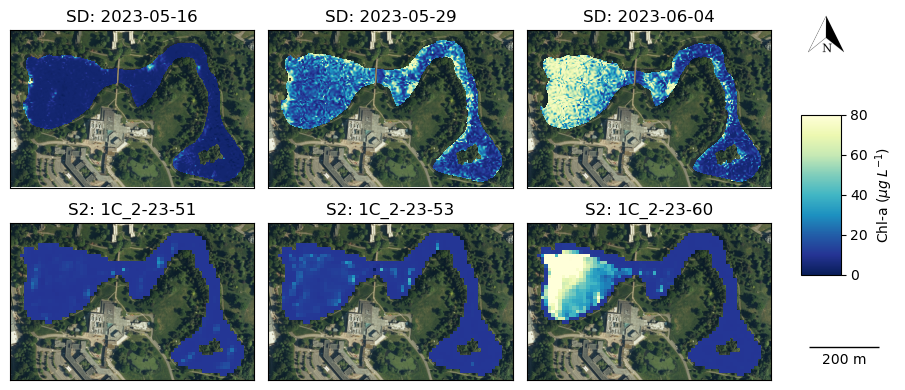

In [119]:
# note: we are working in EPSG:32630, where units are metres

fig, axs = plt.subplots(2, 3, figsize=(10, 4))

# s2_images = ['S2B_MSI_2023_05_15_11_45_39_T30VVH_L2W.tif',
#              'S2A_MSI_2023_05_30_11_45_39_T30VVH_L2W.tif',
#              'S2B_MSI_2023_06_04_11_45_40_T30VVH_L2W.tif',
#              'S2A_MSI_2023_06_16_11_35_43_T30VVH_L2W.tif',
#              'S2A_MSI_2023_07_09_11_45_41_T30VVH_L2W.tif',
#              'S2A_MSI_2023_07_19_11_45_40_T30VVH_L2W.tif']

s2_images = ['S2B_MSIL1C_20230515T114359_N0509_R123_T30VVH_20230515T121402.tif',
             'S2A_MSIL1C_20230530T114351_N0509_R123_T30VVH_20230530T152105.tif',
             'S2B_MSIL1C_20230604T114349_N0509_R123_T30VVH_20230604T121616.tif',
             'S2A_MSIL1C_20230616T113321_N0509_R080_T30VVH_20230616T164926.tif',
             'S2A_MSIL1C_20230709T114351_N0509_R123_T30VVH_20230709T152302.tif',
             'S2A_MSIL1C_20230719T114351_N0509_R123_T30VVH_20230719T152101.tif']

planet_images = ['PlanetScope_24b4_2023_05_16_10_30_33_L2W.tif',
                 'PlanetScope_242b_2023_05_29_10_21_47_L2W.tif',
                 'PlanetScope_2440_2023_06_04_10_26_56_L2W.tif',
                 'PlanetScope_24b9_2023_06_16_10_29_24_L2W.tif',
                 'PlanetScope_242d_2023_07_08_10_29_51_L2W.tif',
                 'PlanetScope_24b3_2023_07_21_10_34_37_L2W.tif']

# axs = axs.reshape((5, 2))


for i, sensor, band in zip([0, 1], ['planet/', 'Sentinel2/c2rcc_CX/'], [20, 2 #28 
                                                               ]):
    for ax, image in zip(axs[i, :], [planet_images[:-3], s2_images[:-3]][i]):
        
        if sensor == 'planet/':
            title = 'SD: ' + image[17:21] + '-' + image[22:24] + '-' + image[25:27]
        else:
            title = 'S2: ' + image[8:12] + '-' + image[13:15] + '-' + image[16:18]
            
        ax.set_title(title)

        with rasterio.open('map_stuff/aerial_merged_32630.tif') as src:
            show(src.read(), transform=src.transform,adjust=True, ax=ax)

        with rasterio.open('map_stuff/rasters/' + sensor + image) as src:
            # use imshow so that we have something to map the colorbar to
            c = ax.imshow(src.read(band), 
                                     cmap='YlGnBu_r', 
                                     vmin=0, 
                                     vmax=80)

        with rasterio.open('map_stuff/rasters/' + sensor + image) as src:
            show(src.read(band), transform=src.transform, cmap='YlGnBu_r',
                 vmin=0, vmax=80, ax=ax)

        ax.set_xlim(442550, 443250)
        ax.set_ylim(6222550, 6223000)
        
        
        ax.tick_params(axis='x',          # changes apply to the x-axis
                       which='both',      # both major and minor ticks are affected
                       bottom=False,      # ticks along the bottom edge are off
                       top=False,         # ticks along the top edge are off
                       labelbottom=False) # labels along the bottom edge are off

        ax.tick_params(axis='y',          # changes apply to the x-axis
                       which='both',      # both major and minor ticks are affected
                       left=False,      # ticks along the bottom edge are off
                       right=False,         # ticks along the top edge are off
                       labelleft=False) # labels along the bottom edge are off
        
        scalebar = AnchoredSizeBar(ax.transData,
                                   200, '200 m', 'lower left', 
                                   pad=0.5,
                                   sep=4,
                                   color='black',
                                   frameon=False,
                                   size_vertical=1,
                                   #fontproperties=fontprops
                                  )

        


# fig.subplots_adjust(right=0.85)

cbar_ax = fig.add_axes([0.81, 0.3, 0.04, 0.4]) # (left, bottom, width, height)
fig.colorbar(c, cax=cbar_ax, label='Chl-a ($\mu g \: L^{-1}$)')

scale_ax = fig.add_axes([0.81, 0.05, 0.04, 0.1]) # (left, bottom, width, height)
scale_ax.axis('off')
# scale_ax.add_artist(scalebar)

arrow_ax = fig.add_axes([0.81, 0.8, 0.05, 0.2]) # (left, bottom, width, height)
arrow_ax.axis('off')

scale_ax.add_artist(scalebar)

# arrow_ax.arrow(0.04, 0.04, 0, 0.0002, color='k',
#                width=0.0005, head_length=0.00003, 
#                length_includes_head=True, alpha=0.1)

# arrow_ax.annotate("N", xy=(1.02, 0.6), xytext=(1.02, 0.8),
#              arrowprops=dict(arrowstyle="<-", lw=1,),
#                   horizontalalignment="center",
                  
#                  )


# arrow_ax.text(1.7, 0.7, "  ",
#             ha="center", va="center", rotation=90, size=12,
#             bbox=dict(boxstyle="rarrow,pad=0.3",
#                       fc='white', ec="k", lw=1))


# t = arrow_ax.text(1.7, 0.7, "N", 
#             ha="center", va="center", rotation=0, size=12,
#               backgroundcolor=None,
# )

# t.set_bbox(dict(alpha=0.))

arrow_ax.imshow(northArrow,
                cmap=matplotlib.colors.ListedColormap(['black', 'none'])
)

fig.tight_layout(rect=[0.0, 0.0, 0.8, 1]) # rect: tuple (left, bottom, right, top), default: (0, 0, 1, 1)
# plt.savefig('figs_for_presentation/map_test2_pres.svg', dpi=300)

plt.show()

<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85291/1233483020.py:42: SyntaxWarning: invalid escape sequence '\m'
  fig.colorbar(c, cax=cbar_ax, label='Chl-a ($\mu g \: L^{-1}$)')
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85291/1233483020.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.0, 0.0, 0.8, 1]) # rect: tuple (left, bottom, right, top), default: (0, 0, 1, 1)


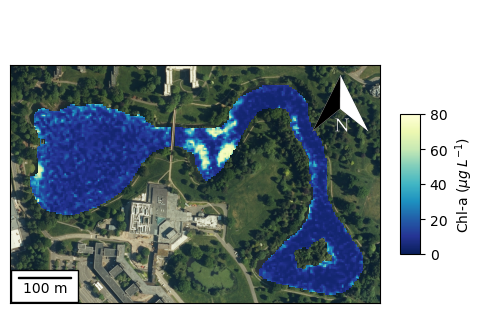

In [30]:
northArrow3 = open_image_local('map_stuff/north_arrow2_invert.png')

# note: we are working in EPSG:32630, where units are metres

fig, ax = plt.subplots(figsize=(5, 3.5))

with rasterio.open('map_stuff/aerial_merged_32630.tif') as src:
            show(src.read(), transform=src.transform,adjust=True, ax=ax)

with rasterio.open('map_stuff/rasters/planet/PlanetScope_24b9_2023_06_16_10_29_24_L2W.tif') as src:
    # use imshow so that we have something to map the colorbar to
    c = ax.imshow(src.read(20), 
                             cmap='YlGnBu_r', 
                             vmin=0, 
                             vmax=80)

with rasterio.open('map_stuff/rasters/planet/PlanetScope_24b9_2023_06_16_10_29_24_L2W.tif') as src:
    show(src.read(20), transform=src.transform, cmap='YlGnBu_r',
         vmin=0, vmax=80, ax=ax)

ax.set_xlim(442550, 443250)
ax.set_ylim(6222550, 6223000)


ax.tick_params(axis='x',          # changes apply to the x-axis
               which='both',      # both major and minor ticks are affected
               bottom=False,      # ticks along the bottom edge are off
               top=False,         # ticks along the top edge are off
               labelbottom=False) # labels along the bottom edge are off

ax.tick_params(axis='y',          # changes apply to the x-axis
               which='both',      # both major and minor ticks are affected
               left=False,      # ticks along the bottom edge are off
               right=False,         # ticks along the top edge are off
               labelleft=False) # labels along the bottom edge are off



# fig.subplots_adjust(right=0.85)

cbar_ax = fig.add_axes([0.81, 0.3, 0.04, 0.4]) # (left, bottom, width, height)
fig.colorbar(c, cax=cbar_ax, label='Chl-a ($\mu g \: L^{-1}$)')



arrow_ax = fig.add_axes([0.81, 0.8, 0.05, 0.2]) # (left, bottom, width, height)
arrow_ax.axis('off')

scalebar = AnchoredSizeBar(ax.transData,
                           100, '100 m', 'lower left', 
                           pad=0.5,
                           sep=2,
                           color='black',
                           frameon=True,
                           size_vertical=1,
                           #fontproperties=fontprops
                          )

ax.add_artist(scalebar)


ax.imshow(northArrow3,
          cmap='Greys_r',
#                 cmap=matplotlib.colors.ListedColormap(['white', 'white']),
          extent=[443100, 443250, 6222850, 6223000] # (left, right, bottom, top)
            )    

fig.tight_layout(rect=[0.0, 0.0, 0.8, 1]) # rect: tuple (left, bottom, right, top), default: (0, 0, 1, 1)
plt.savefig('figures_for_paper/floating_heart.svg', dpi=300)

plt.show()

[[442000.0, 6222000.0], [442500.0, 6222250.0], [443000.0, 6222500.0], [443500.0, 6222750.0], [444000.0, 6223000.0], [444500.0, 6223250.0]]
[[-3.9333476069454187, 56.13951763083052], [-3.9253566463754255, 56.14182402678309], [-3.9173647247738814, 56.14412990830115], [-3.9093718421912036, 56.1464352752499], [-3.901377998677966, 56.14874012749458], [-3.893383194284895, 56.151044464900345]]


/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/1713604362.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(coord[0], 3)) for coord in new_coords])
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/1713604362.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(round(coord[1], 3)) for coord in new_coords])


[Text(0, 6222000.0, '56.14'),
 Text(0, 6222250.0, '56.142'),
 Text(0, 6222500.0, '56.144'),
 Text(0, 6222750.0, '56.146'),
 Text(0, 6223000.0, '56.149'),
 Text(0, 6223250.0, '56.151'),
 Text(0, 6223500.0, '')]

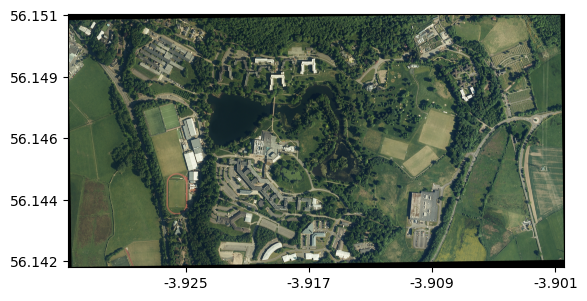

In [23]:
def reproject_coords(src_crs, dst_crs, coords):
    xs = [c[0] for c in coords]
    ys = [c[1] for c in coords]
    xs, ys = fiona.transform.transform(src_crs, dst_crs, xs, ys)
    return [[x,y] for x,y in zip(xs, ys)]

fig, ax = plt.subplots()

with rasterio.open('map_stuff/aerial_merged_32630.tif') as src:
            show(src.read(), transform=src.transform,adjust=True,
                 ax=ax)\

src_crs = 'EPSG:32630'
dst_crs = 'EPSG:4326'

ax.locator_params(nbins=5)


xs = ax.get_xticks()
ys = ax.get_yticks()

coords = [[x, y] for x, y in zip(xs, ys)]
print(coords)
new_coords = reproject_coords(src_crs, dst_crs, coords)
print(new_coords)

ax.set_xticklabels([str(round(coord[0], 3)) for coord in new_coords])
ax.set_yticklabels([str(round(coord[1], 3)) for coord in new_coords])

In [16]:
round(56.9128398129381, 3)
round(-3.9128398129381, 3)

-3.913

<>:109: SyntaxWarning: invalid escape sequence '\d'
<>:110: SyntaxWarning: invalid escape sequence '\d'
<>:109: SyntaxWarning: invalid escape sequence '\d'
<>:110: SyntaxWarning: invalid escape sequence '\d'
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/3206738130.py:109: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xlabel('Longitude ($\degree$)')
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/3206738130.py:110: SyntaxWarning: invalid escape sequence '\d'
  ax.set_ylabel('Latitude ($\degree$)')
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/3206738130.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(coord[0], 3)) for coord in new_coords])
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85178/3206738130.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

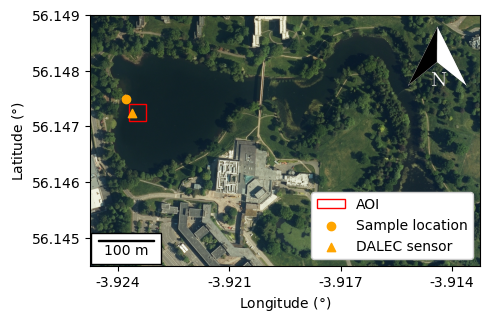

In [29]:
northArrow3 = open_image_local('map_stuff/north_arrow2_invert.png')

fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))
with rasterio.open('map_stuff/aerial_merged_32630.tif') as src:
            show(src.read(), transform=src.transform,adjust=True,
                 ax=ax)
        
ax.set_xlim(442550, 443250)
ax.set_ylim(6222550, 6223000)

scalebar = AnchoredSizeBar(ax.transData,
                           100, '100 m', 'lower left', 
                           pad=0.5,
                           sep=2,
                           color='black',
                           frameon=True,
                           size_vertical=1,
                           #fontproperties=fontprops
                          )

ax.add_artist(scalebar)

# 442634.8257971745, 6222824.910507713 is the centre of the box 10 m east of the dalec

# for i in range(10):
#     for j in range(10):
#         rect = patches.Rectangle((442634.8257971745-i*3 + 12,
#                                   6222824.910507713- j*3 + 12), 3, 3,
#                                  linewidth=0.5, edgecolor='r', facecolor='none')

#         # Add the patch to the Axes
#         ax.add_patch(rect)
        
# for i in range(3):
#     for j in range(3):
#         rect = patches.Rectangle((442634.8257971745-i*10 + 5,
#                                   6222824.910507713- j*10 + 5), 10, 10,
#                                  linewidth=0.5, edgecolor='green', facecolor='none')

#         # Add the patch to the Axes
#         ax.add_patch(rect)
        
rect = patches.Rectangle((442634.8257971745 - 15,
                          6222824.910507713 - 15), 30, 30,
                         linewidth=1, edgecolor='r', facecolor='none',
                         label='AOI')

# Add the patch to the Axes
ax.add_patch(rect)

ax.scatter([442634.8257971745-20], [6222824.910507713+25],
           marker='o', color='orange', label='Sample location')

ax.scatter([442634.8257971745-10], [6222824.910507713],
           marker='^', color='orange', label='DALEC sensor')


        
# rect = patches.Rectangle((442634.8257971745,
#                           6222824.910507713), 15, 15,
#                                  linewidth=0.5, edgecolor='orange', facecolor='none')

# # Add the patch to the Axes
# ax.add_patch(rect)


ax.imshow(northArrow3,
          cmap='Greys_r',
#                 cmap=matplotlib.colors.ListedColormap(['white', 'white']),
          extent=[443100, 443250, 6222850, 6223000] # (left, right, bottom, top)
            )    

# ax.tick_params(axis='x',          # changes apply to the x-axis
#                which='both',      # both major and minor ticks are affected
#                bottom=False,      # ticks along the bottom edge are off
#                top=False,         # ticks along the top edge are off
#                labelbottom=False) # labels along the bottom edge are off

# ax.tick_params(axis='y',          # changes apply to the x-axis
#                which='both',      # both major and minor ticks are affected
#                left=False,      # ticks along the bottom edge are off
#                right=False,         # ticks along the top edge are off
#                labelleft=False) # labels along the bottom edge are off

ax.legend(loc='lower right', framealpha=1)


def reproject_coords(src_crs, dst_crs, coords):
    xs = [c[0] for c in coords]
    ys = [c[1] for c in coords]
    xs, ys = fiona.transform.transform(src_crs, dst_crs, xs, ys)
    return [[x,y] for x,y in zip(xs, ys)]

src_crs = 'EPSG:32630'
dst_crs = 'EPSG:4326'

ax.locator_params(nbins=5)


xs = ax.get_xticks()
ys = ax.get_yticks()

coords = [[x, y] for x, y in zip(xs, ys)]
new_coords = reproject_coords(src_crs, dst_crs, coords)

ax.set_xticklabels([str(round(coord[0], 3)) for coord in new_coords])
ax.set_yticklabels([str(round(coord[1], 3)) for coord in new_coords])

ax.set_xlabel('Longitude ($\degree$)')
ax.set_ylabel('Latitude ($\degree$)')


fig.tight_layout()

plt.savefig('figures_for_paper/basemap_lat_lon.svg', dpi=1000)

        

In [30]:
for i in range(3):
    for j in range(3):
        print(i, j)

0 0
0 1
0 2
1 0
1 1
1 2
2 0
2 1
2 2


In [240]:
'PlanetScope_24b4_2023_05_16_10_30_33_L2W.tif'[17:21]

'2023'

In [243]:
'PlanetScope_24b4_2023_05_16_10_30_33_L2W.tif'[22:24]

'05'

In [244]:
'PlanetScope_24b4_2023_05_16_10_30_33_L2W.tif'[25:27]

'16'

In [250]:
'S2A_MSI_2023_07_09_11_45_41_T30VVH_L2W.tif'[8:12]

'2023'

In [252]:
'S2A_MSI_2023_07_09_11_45_41_T30VVH_L2W.tif'[13:15]

'07'

In [254]:
'S2A_MSI_2023_07_09_11_45_41_T30VVH_L2W.tif'[16:18]

'09'

In [4]:
planet_images[:-2]

['PlanetScope_24b4_2023_05_16_10_30_33_L2W.tif',
 'PlanetScope_242b_2023_05_29_10_21_47_L2W.tif',
 'PlanetScope_2440_2023_06_04_10_26_56_L2W.tif',
 'PlanetScope_24b9_2023_06_16_10_29_24_L2W.tif']

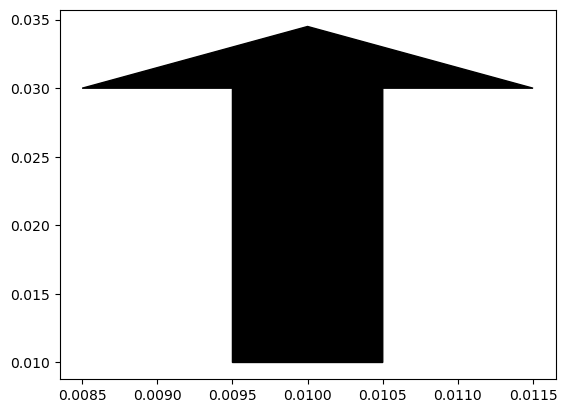

In [11]:
fig, arrow_ax = plt.subplots()
arrow_ax.annotate("N", xy=(0., 0.0), xytext=(0., 0.),
#             arrowprops=dict(arrowstyle="<-")
                 )

arrow_ax.arrow(0.01, 0.01, 0, 0.02, color='k')

AttributeError: AxesImage.set() got an unexpected keyword argument 'scale'

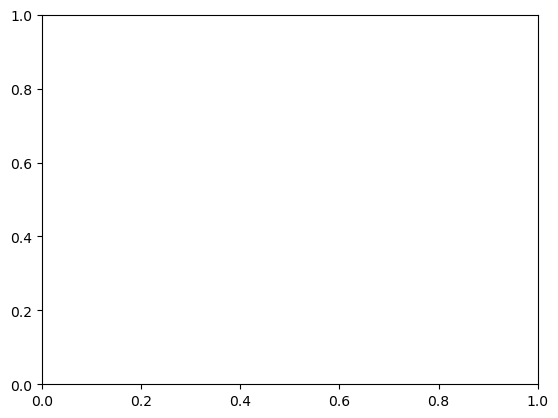